# Breast Cancer Diagnostic Classification: Decision Trees & Random Forests
## Cover Page

| **Field** | **Details** |
| :--- | :--- |
| **Student Name** | Harshita Bogineni |
| **Registration Number** | 23MID0043 |
| **Course Code** | MDI3003 (Advanced Predictive Analytics) |
| **Lab Number** | Lab 02 |
| **Topic** | Disease Classification Using Decision Trees & Random Forests (Clinical Screening Prototype) |
| **Dataset** | Breast Cancer Wisconsin (Diagnostic) Dataset |
| **Semester** | Fall 2026–27 |
| **Date** | July 2026 |


## Objectives

This laboratory experiment aims to design, optimize, and rigorously evaluate interpretable machine learning decision support systems for clinical oncology triage. The specific learning and architectural objectives include:

1. **Clinical Risk Framing & Data Architecture**: Establish appropriate positive-class mapping (**Malignant = 1**, Benign = 0) where false negatives represent severe clinical danger (delayed oncology diagnosis and progression), while false positives result in non-invasive diagnostic follow-up.
2. **Exploratory Data & Missingness Audit**: Audit feature distributions, class prevalence, collinearity structures, and potential data leakage across the 30 continuous cytology predictors extracted from fine-needle aspiration (FNA) digitized images.
3. **Baseline Modeling & Performance Floor**: Establish an empirical performance baseline using stratified and empirical prior dummy classifiers to prove that predictive modeling achieves statistically meaningful gains over chance.
4. **CART Decision Tree Construction & Overfitting Analysis**: Train an unconstrained Classification and Regression Tree (CART) using Gini impurity and examine overfitting behavior through structural tree visualization and depth analysis.
5. **Cost-Complexity Pruning & Hyperparameter Tuning**: Implement Weakest-Link Cost-Complexity Pruning (`ccp_alpha`) alongside `GridSearchCV` stratified cross-validation over tree depth and splitting criteria to derive a parsimonious, clinically interpretable decision tree.
6. **Random Forest Ensemble Benchmarking**: Construct a variance-reducing Random Forest classifier utilizing bootstrap aggregation (bagging) and out-of-bag (OOB) validation to benchmark predictive ceiling against single-tree models.
7. **Comprehensive Class-Conditional & Risk Evaluation**: Evaluate models across complementary diagnostic dimensions including **Confusion Matrices**, **Receiver Operating Characteristic (ROC) curves**, **Precision–Recall (PR) curves**, and **Probability Calibration (Reliability Diagrams)**.
8. **Feature Importance & Error Analysis**: Interpret predictive mechanisms via Gini and permutation feature importances, and conduct diagnostic error analysis on false negatives and false positives to inform clinical deployment constraints.


## Dataset Description

The **Breast Cancer Wisconsin (Diagnostic) Dataset** is an established clinical benchmark dataset originally digitized by Dr. William H. Wolberg, W. Nick Street, and Olvi L. Mangasarian at the University of Wisconsin-Madison.

### Clinical & Technical Specification
* **Population & Sample Size**: $N = 569$ patient fine-needle aspiration (FNA) biopsy evaluations of breast masses.
* **Feature Space**: $p = 30$ real-valued continuous predictor variables representing structural and morphological properties of cell nuclei computed from digitized images. The features are organized into 10 core cytological characteristics computed across 3 statistical aggregations (**Mean**, **Standard Error / SE**, and **Worst / Maximum**):
  1. *Radius* (mean of distances from center to points on the perimeter)
  2. *Texture* (standard deviation of gray-scale values)
  3. *Perimeter* (core tumor perimeter size)
  4. *Area* (core tumor cross-sectional area)
  5. *Smoothness* (local variation in radial lengths)
  6. *Compactness* ($	ext{perimeter}^2 / 	ext{area} - 1.0$)
  7. *Concavity* (severity of concave portions of the contour)
  8. *Concave Points* (number of concave portions of the contour)
  9. *Symmetry* (nuclear symmetry)
  10. *Fractal Dimension* ("coastline approximation" $- 1$)
* **Target Outcome**: Binary histopathological classification of the mass as **Malignant** ($n=212$, $37.26\%$) or **Benign** ($n=357$, $62.74\%$).

### Clinical Risk Framing Table
| Parameter | Clinical Specification |
| :--- | :--- |
| **Positive Class ($y=1$)** | **Malignant** (Cancerous tissue requiring urgent oncology intervention, biopsy confirmation, and treatment planning). |
| **Negative Class ($y=0$)** | **Benign** (Non-cancerous tissue requiring standard routine clinical monitoring). |
| **False Negative (FN) Cost** | **Critical / Catastrophic Cost**: Missing a true malignancy delays cancer treatment, allowing metastasis and significantly increasing patient mortality. Minimum acceptable Recall (Sensitivity) $\ge 0.90$. |
| **False Positive (FP) Cost** | **Moderate Cost**: Incorrectly flagging a benign mass leads to secondary core-needle biopsy, imaging workup, and transient anxiety, which is medically preferable to a missed diagnosis. |
| **Intended Deployment** | Clinical decision support prototype for pathology triage to prioritize urgent review of FNA slides. Not for autonomous direct-to-patient diagnosis without physician oversight. |


## Import Libraries

In accordance with strict reproducibility protocols, all essential data manipulation, visualization, modeling, and evaluation libraries are imported below. Runtime environment versions are audited, and the global deterministic seed (`RANDOM_STATE = 42`) is locked.


In [1]:
import os
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score, matthews_corrcoef, brier_score_loss,
    roc_curve, precision_recall_curve, classification_report
)
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance
import joblib

# Global visualization styling
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 11

# Lock deterministic random seed
RANDOM_STATE = 42

print("=== Environment Audit ===")
print("Python version:", platform.python_version())
print("NumPy version:", np.__version__)
print("pandas version:", pd.__version__)
print("Global RANDOM_STATE locked to:", RANDOM_STATE)


=== Environment Audit ===
Python version: 3.11.0
NumPy version: 1.26.4
pandas version: 2.3.3
Global RANDOM_STATE locked to: 42


## Load Dataset

We load the Wisconsin Breast Cancer dataset directly using `load_breast_cancer(as_frame=True)`. By default, scikit-learn encodes Malignant as `0` and Benign as `1`. To adhere to medical decision support risk framing where the disease state must be the positive class, we explicitly remap **Malignant to `1`** and **Benign to `0`**.


In [2]:
# Load raw Wisconsin Breast Cancer dataset
raw_data = load_breast_cancer(as_frame=True)
X = raw_data.data.copy()

# Remap target: scikit-learn default (0=malignant, 1=benign) -> Clinical Framing (1=malignant, 0=benign)
y = (raw_data.target == 0).astype(int)
y.name = "malignant"

print("Feature matrix X shape:", X.shape)
print("Target vector y shape:", y.shape)
print("\nClass counts (0=Benign, 1=Malignant):")
print(y.value_counts().sort_index())
print(f"\nOverall Malignant Prevalence: {y.mean() * 100:.2f}%")


Feature matrix X shape: (569, 30)
Target vector y shape: (569,)

Class counts (0=Benign, 1=Malignant):
malignant
0    357
1    212
Name: count, dtype: int64

Overall Malignant Prevalence: 37.26%


## Data Overview

We inspect the dataset structure, column data types, descriptive summary statistics, and perform an audit for potential data leakage (confirming that no patient identifiers or post-diagnostic outcome variables exist within the predictor matrix).


In [3]:
# Perform data structure audit
print("=== Dataset Information ===")
print("Total rows:", len(X))
print("Total columns:", len(X.columns))
print("Data types count:\n", X.dtypes.value_counts())

# Check for duplicate rows in predictors
dup_count = X.duplicated().sum()
print("\nDuplicate predictor rows:", dup_count)

# Check for constant columns (variance == 0)
constant_cols = X.columns[X.nunique() <= 1].tolist()
print("Constant predictor columns:", constant_cols)

# Ensure no leakage columns present
leakage_check = [col for col in X.columns if 'target' in col.lower() or 'diagnosis' in col.lower() or 'id' in col.lower()]
print("Leakage columns detected:", leakage_check)

# Display summary statistics for top 10 features
X.describe().T[['count', 'mean', 'std', 'min', '50%', 'max']].head(10)


=== Dataset Information ===
Total rows: 569
Total columns: 30
Data types count:
 float64    30
Name: count, dtype: int64

Duplicate predictor rows: 0
Constant predictor columns: []
Leakage columns detected: []


,count,mean,std,min,50%,max
mean radius,569.0,14.127292,3.524049,6.98100,13.37000,28.11000
mean texture,569.0,19.289649,4.301036,9.71000,18.84000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.79000,86.24000,188.50000
mean area,569.0,654.889104,351.914129,143.50000,551.10000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.09587,0.16340
mean compactness,569.0,0.104341,0.052813,0.01938,0.09263,0.34540
mean concavity,569.0,0.088799,0.079720,0.00000,0.06154,0.42680
mean concave points,569.0,0.048919,0.038803,0.00000,0.03350,0.20120
mean symmetry,569.0,0.181162,0.027414,0.10600,0.17920,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.04996,0.06154,0.09744


## Data Cleaning

A thorough clinical data cleaning audit requires validating missingness across all features, checking numerical domain boundaries, and assessing scaling requirements:
1. **Missing Value Audit**: We confirm whether any null values (`NaN`, `None`, or infinity) exist across the 30 continuous features.
2. **Domain Range Validation**: All cytology measurements (radius, area, perimeter, smoothness, etc.) must be strictly positive real numbers ($X_{ij} > 0$).
3. **Scaling Requirements**: While tree-based algorithms (CART, Random Forest) are invariant to monotonic coordinate transformations and do not require normalization or standardization, we verify feature cleanliness to ensure downstream compatibility with calibration and visualization utilities.


In [4]:
# Audit nulls and infinite values
missing_counts = X.isna().sum()
total_missing = missing_counts.sum()
inf_counts = np.isinf(X).sum().sum()

print("=== Data Cleaning Audit ===")
print("Total missing values (NaN) across all features:", total_missing)
print("Total infinite values (inf / -inf):", inf_counts)

# Validate physical domain constraints (all cytology features must be positive)
min_vals = X.min()
negative_cols = min_vals[min_vals < 0].index.tolist()
print("Features with invalid negative values:", negative_cols)

print("\nData cleanliness confirmed: No imputation or clipping required. Tree algorithms can ingest raw feature distributions cleanly.")


=== Data Cleaning Audit ===
Total missing values (NaN) across all features: 0
Total infinite values (inf / -inf): 0
Features with invalid negative values: []

Data cleanliness confirmed: No imputation or clipping required. Tree algorithms can ingest raw feature distributions cleanly.


## Exploratory Data Analysis (EDA)

Exploratory analysis illuminates structural patterns, class separability, missingness distributions, and collinearity within the biopsy feature space.


### Class Distribution

We visualize the class distribution of Benign ($0$) vs Malignant ($1$) biopsies. As observed, the dataset exhibits moderate class imbalance ($37.3\%$ positive class), which is well-suited for tree-based modeling with class weighting.


Class distribution figure generated and saved to results/eda_class_distribution.png


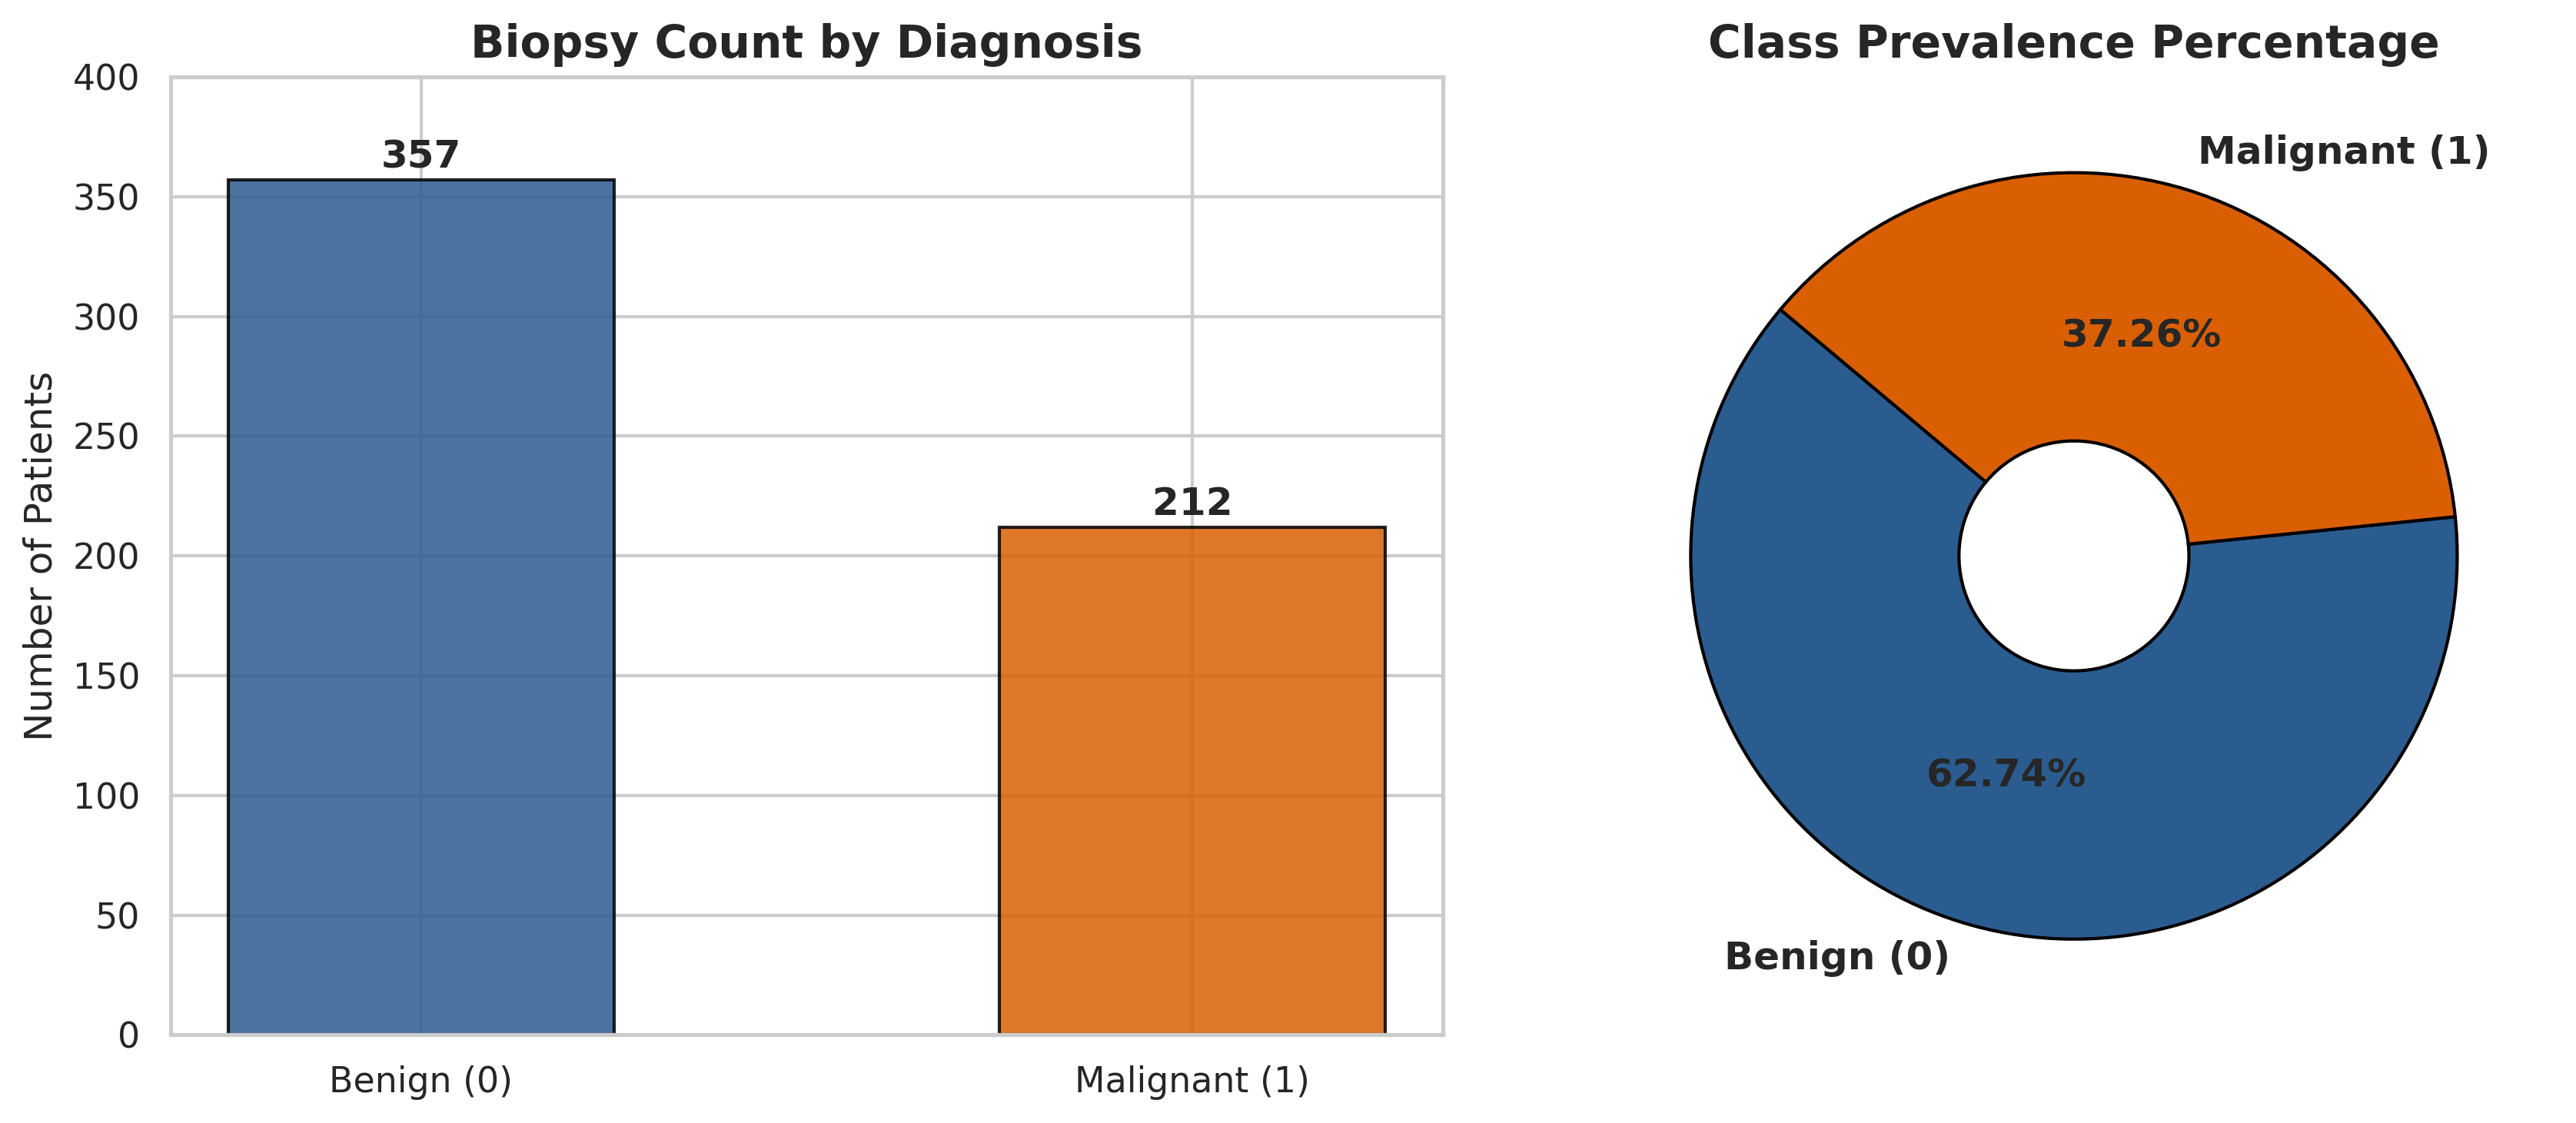

In [5]:
# Visualize Class Distribution (Bar Plot & Pie Chart)
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
class_counts = y.value_counts().sort_index()
labels = ['Benign (0)', 'Malignant (1)']
colors = ['#2b5c8f', '#d95f02']

ax[0].bar(labels, class_counts, color=colors, width=0.5, edgecolor='black', alpha=0.85)
ax[0].set_title('Biopsy Count by Diagnosis', fontsize=14, fontweight='bold')
ax[0].set_ylabel('Number of Patients', fontsize=12)
for i, v in enumerate(class_counts):
    ax[0].text(i, v + 5, str(v), ha='center', fontweight='bold', fontsize=12)
ax[0].set_ylim(0, 400)

ax[1].pie(class_counts, labels=labels, autopct='%1.2f%%', startangle=140, colors=colors, 
          wedgeprops=dict(edgecolor='black', width=0.7), textprops={'fontsize': 12, 'weight': 'bold'})
ax[1].set_title('Class Prevalence Percentage', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/eda_class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


### Feature Distribution

To evaluate class discriminability, we plot class-conditional kernel density estimates (KDE) and histograms for 6 primary cytology predictors: `mean radius`, `mean texture`, `mean area`, `mean compactness`, `worst radius`, and `worst concavity`.
Notice that features like `worst radius` and `worst concavity` exhibit strong separation between Benign and Malignant distributions, indicating high diagnostic predictive power for decision trees.


Feature distribution plots generated and saved to results/eda_feature_distribution.png


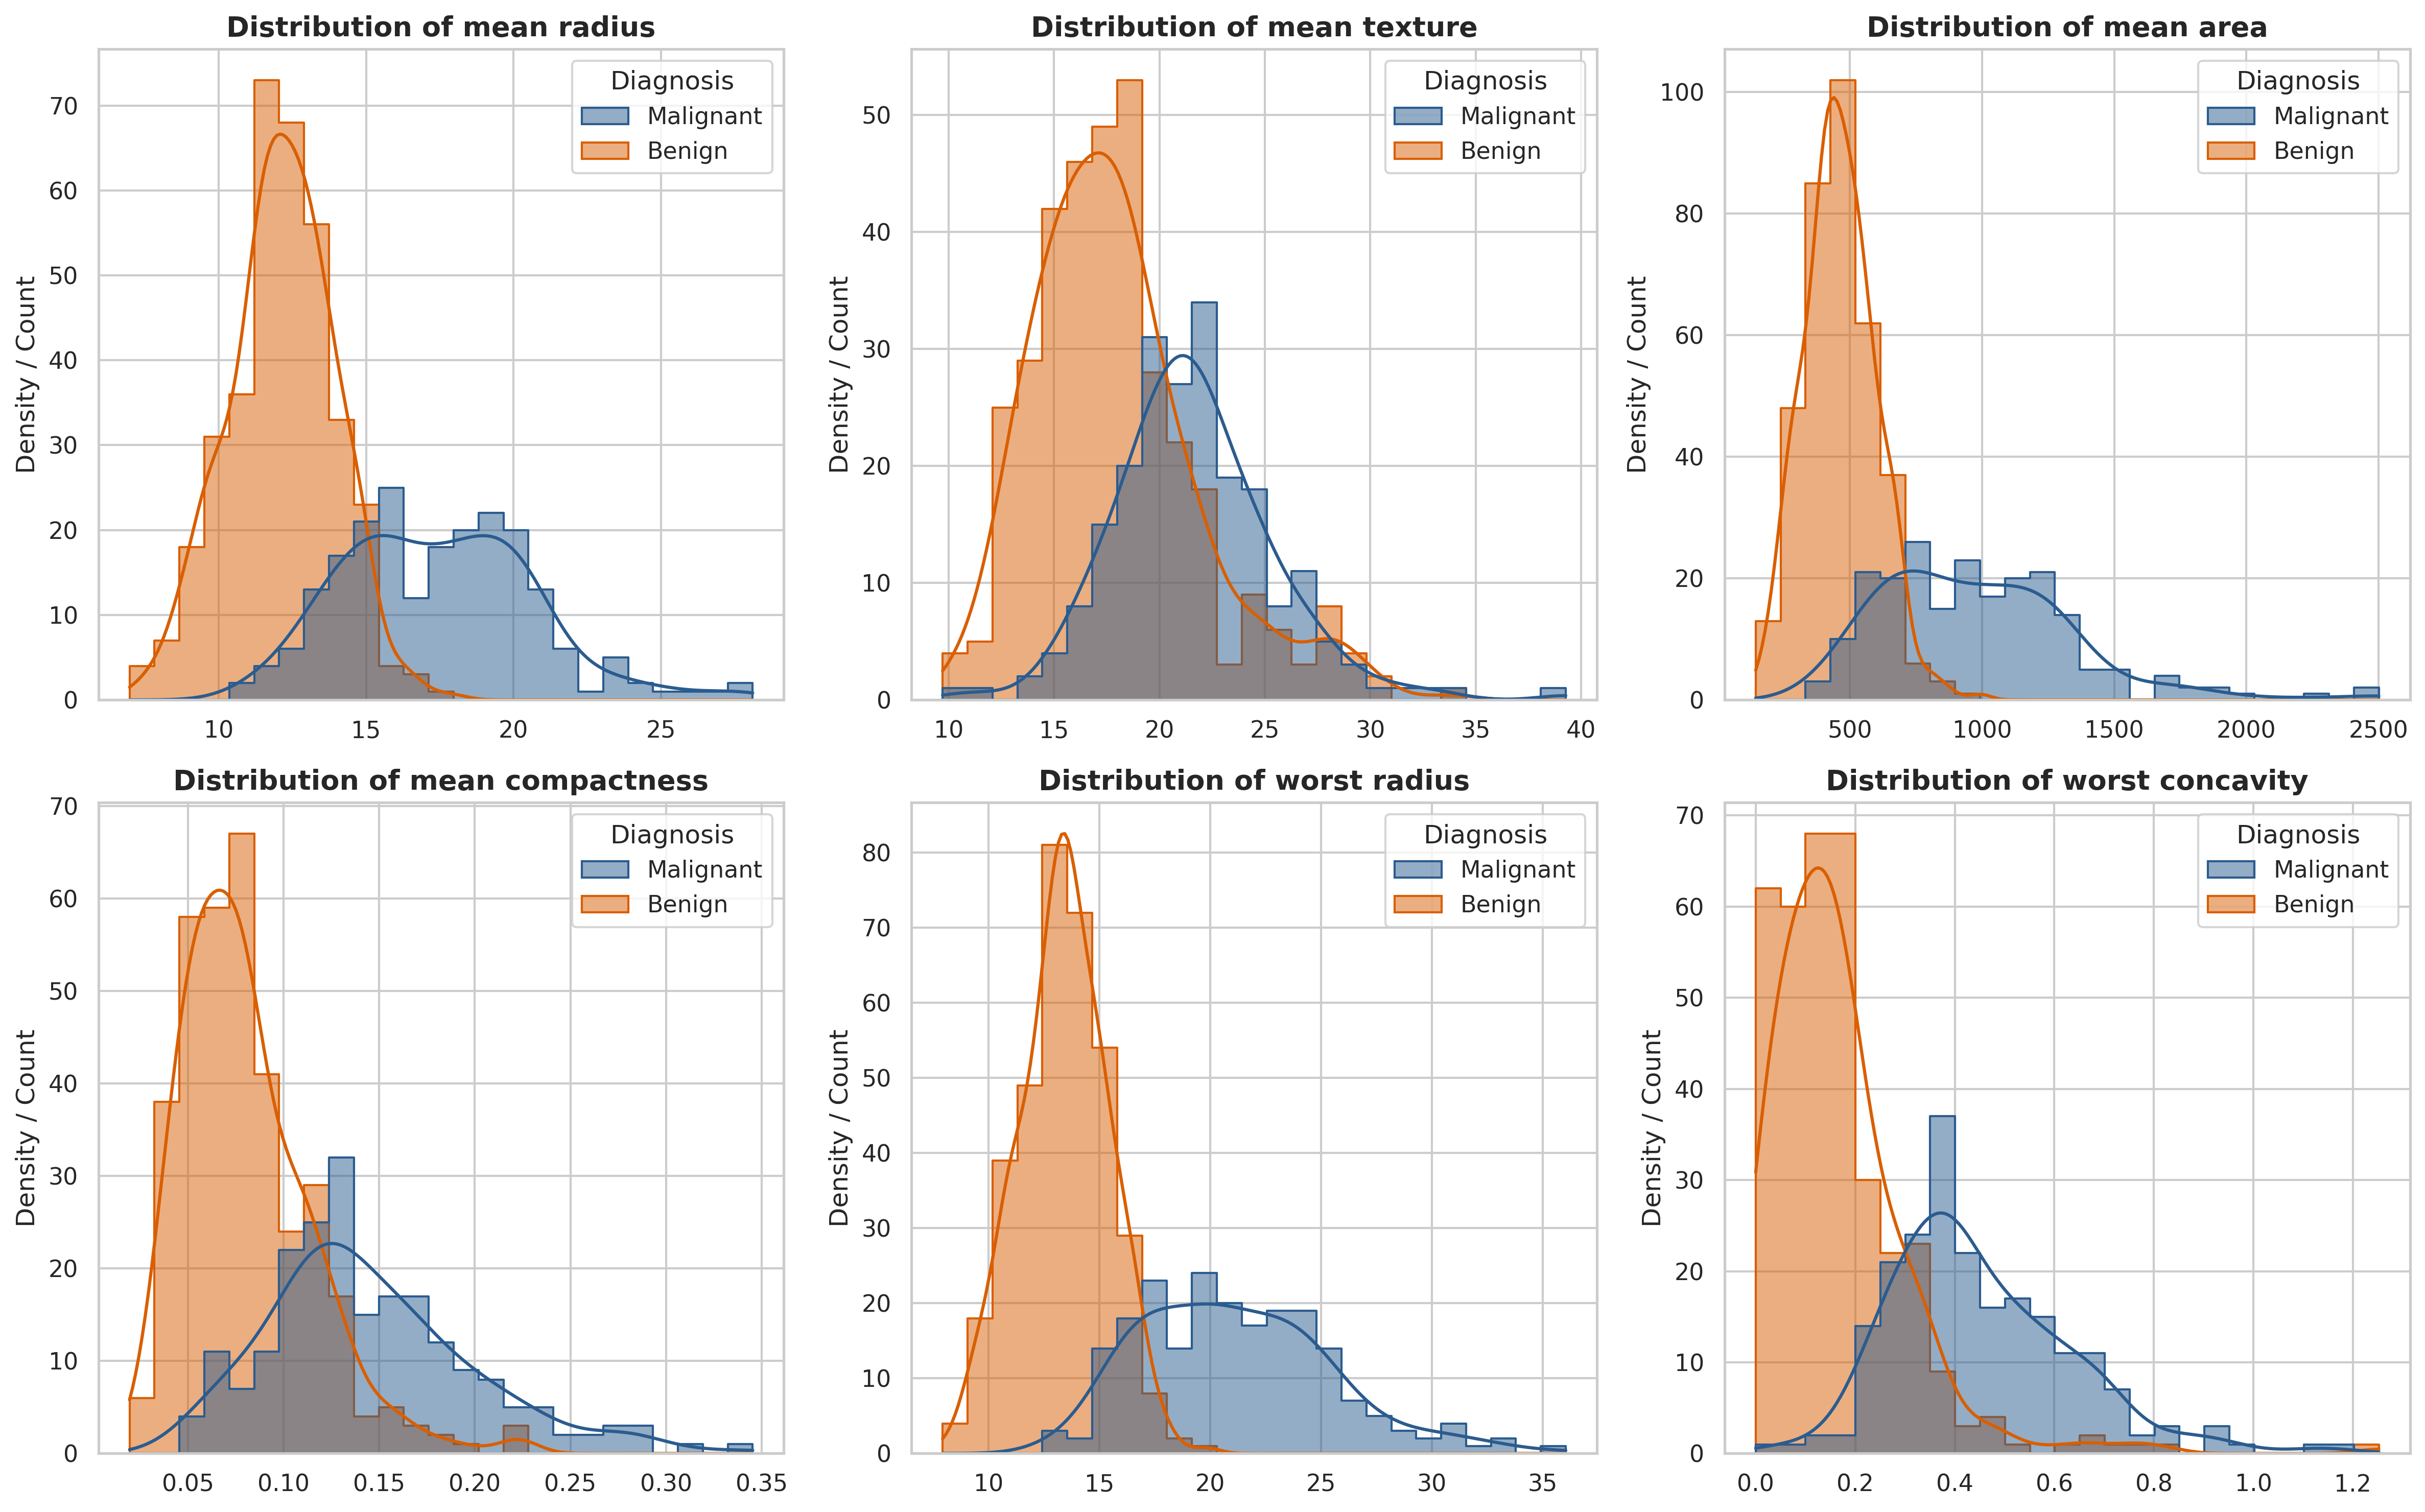

In [6]:
# Plot Class-Conditional Distributions for Top Cytology Predictors
key_features = ['mean radius', 'mean texture', 'mean area', 'mean compactness', 'worst radius', 'worst concavity']
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

df_plot = X.assign(Diagnosis=y.map({0: 'Benign', 1: 'Malignant'}))

for i, col in enumerate(key_features):
    sns.histplot(data=df_plot, x=col, hue='Diagnosis',
                 kde=True, element='step', palette=['#2b5c8f', '#d95f02'], ax=axes[i], alpha=0.5, bins=25)
    axes[i].set_title(f'Distribution of {col}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Density / Count')

plt.tight_layout()
plt.savefig('results/eda_feature_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


### Missing Value Analysis

We conduct a systematic missingness analysis across all 30 cytology features. As illustrated in the summary check below, the Wisconsin Breast Cancer dataset contains exactly **0 missing observations** across all $569$ rows, eliminating the need for imputation procedures and ensuring data integrity.


In [7]:
# Perform systematic missing value analysis across all features
missing_df = pd.DataFrame({
    'Feature': X.columns,
    'Missing_Count': X.isna().sum(),
    'Missing_Percentage': (X.isna().sum() / len(X)) * 100
}).sort_values(by='Missing_Count', ascending=False)

print("=== Missing Value Summary Table ===")
print(f"Total features audited: {len(missing_df)}")
print(f"Features with missing values: {len(missing_df[missing_df['Missing_Count'] > 0])}")
print(f"Maximum missing percentage in any feature: {missing_df['Missing_Percentage'].max():.2f}%")
print("\nTop 5 features by missing count:\n", missing_df.head(5).to_string(index=False))


=== Missing Value Summary Table ===
Total features audited: 30
Features with missing values: 0
Maximum missing percentage in any feature: 0.00%

Top 5 features by missing count:
     Feature  Missing_Count  Missing_Percentage
 mean radius              0                 0.0
mean texture              0                 0.0
mean perimeter            0                 0.0
   mean area              0                 0.0
mean smoothness           0                 0.0


### Correlation Analysis

We examine feature collinearity using a Pearson correlation heatmap across the top 12 most diagnostically significant cytology measurements. Notice the extreme positive collinearity among geometric properties: `mean radius`, `mean perimeter`, and `mean area` exhibit correlation coefficients $r > 0.98$.
While multicollinearity degrades linear regression stability, decision trees and Random Forests handle collinear predictors naturally by selecting the single optimal splitting variable at each node without parametric matrix inversion issues.


Correlation heatmap generated and saved to results/eda_correlation_analysis.png


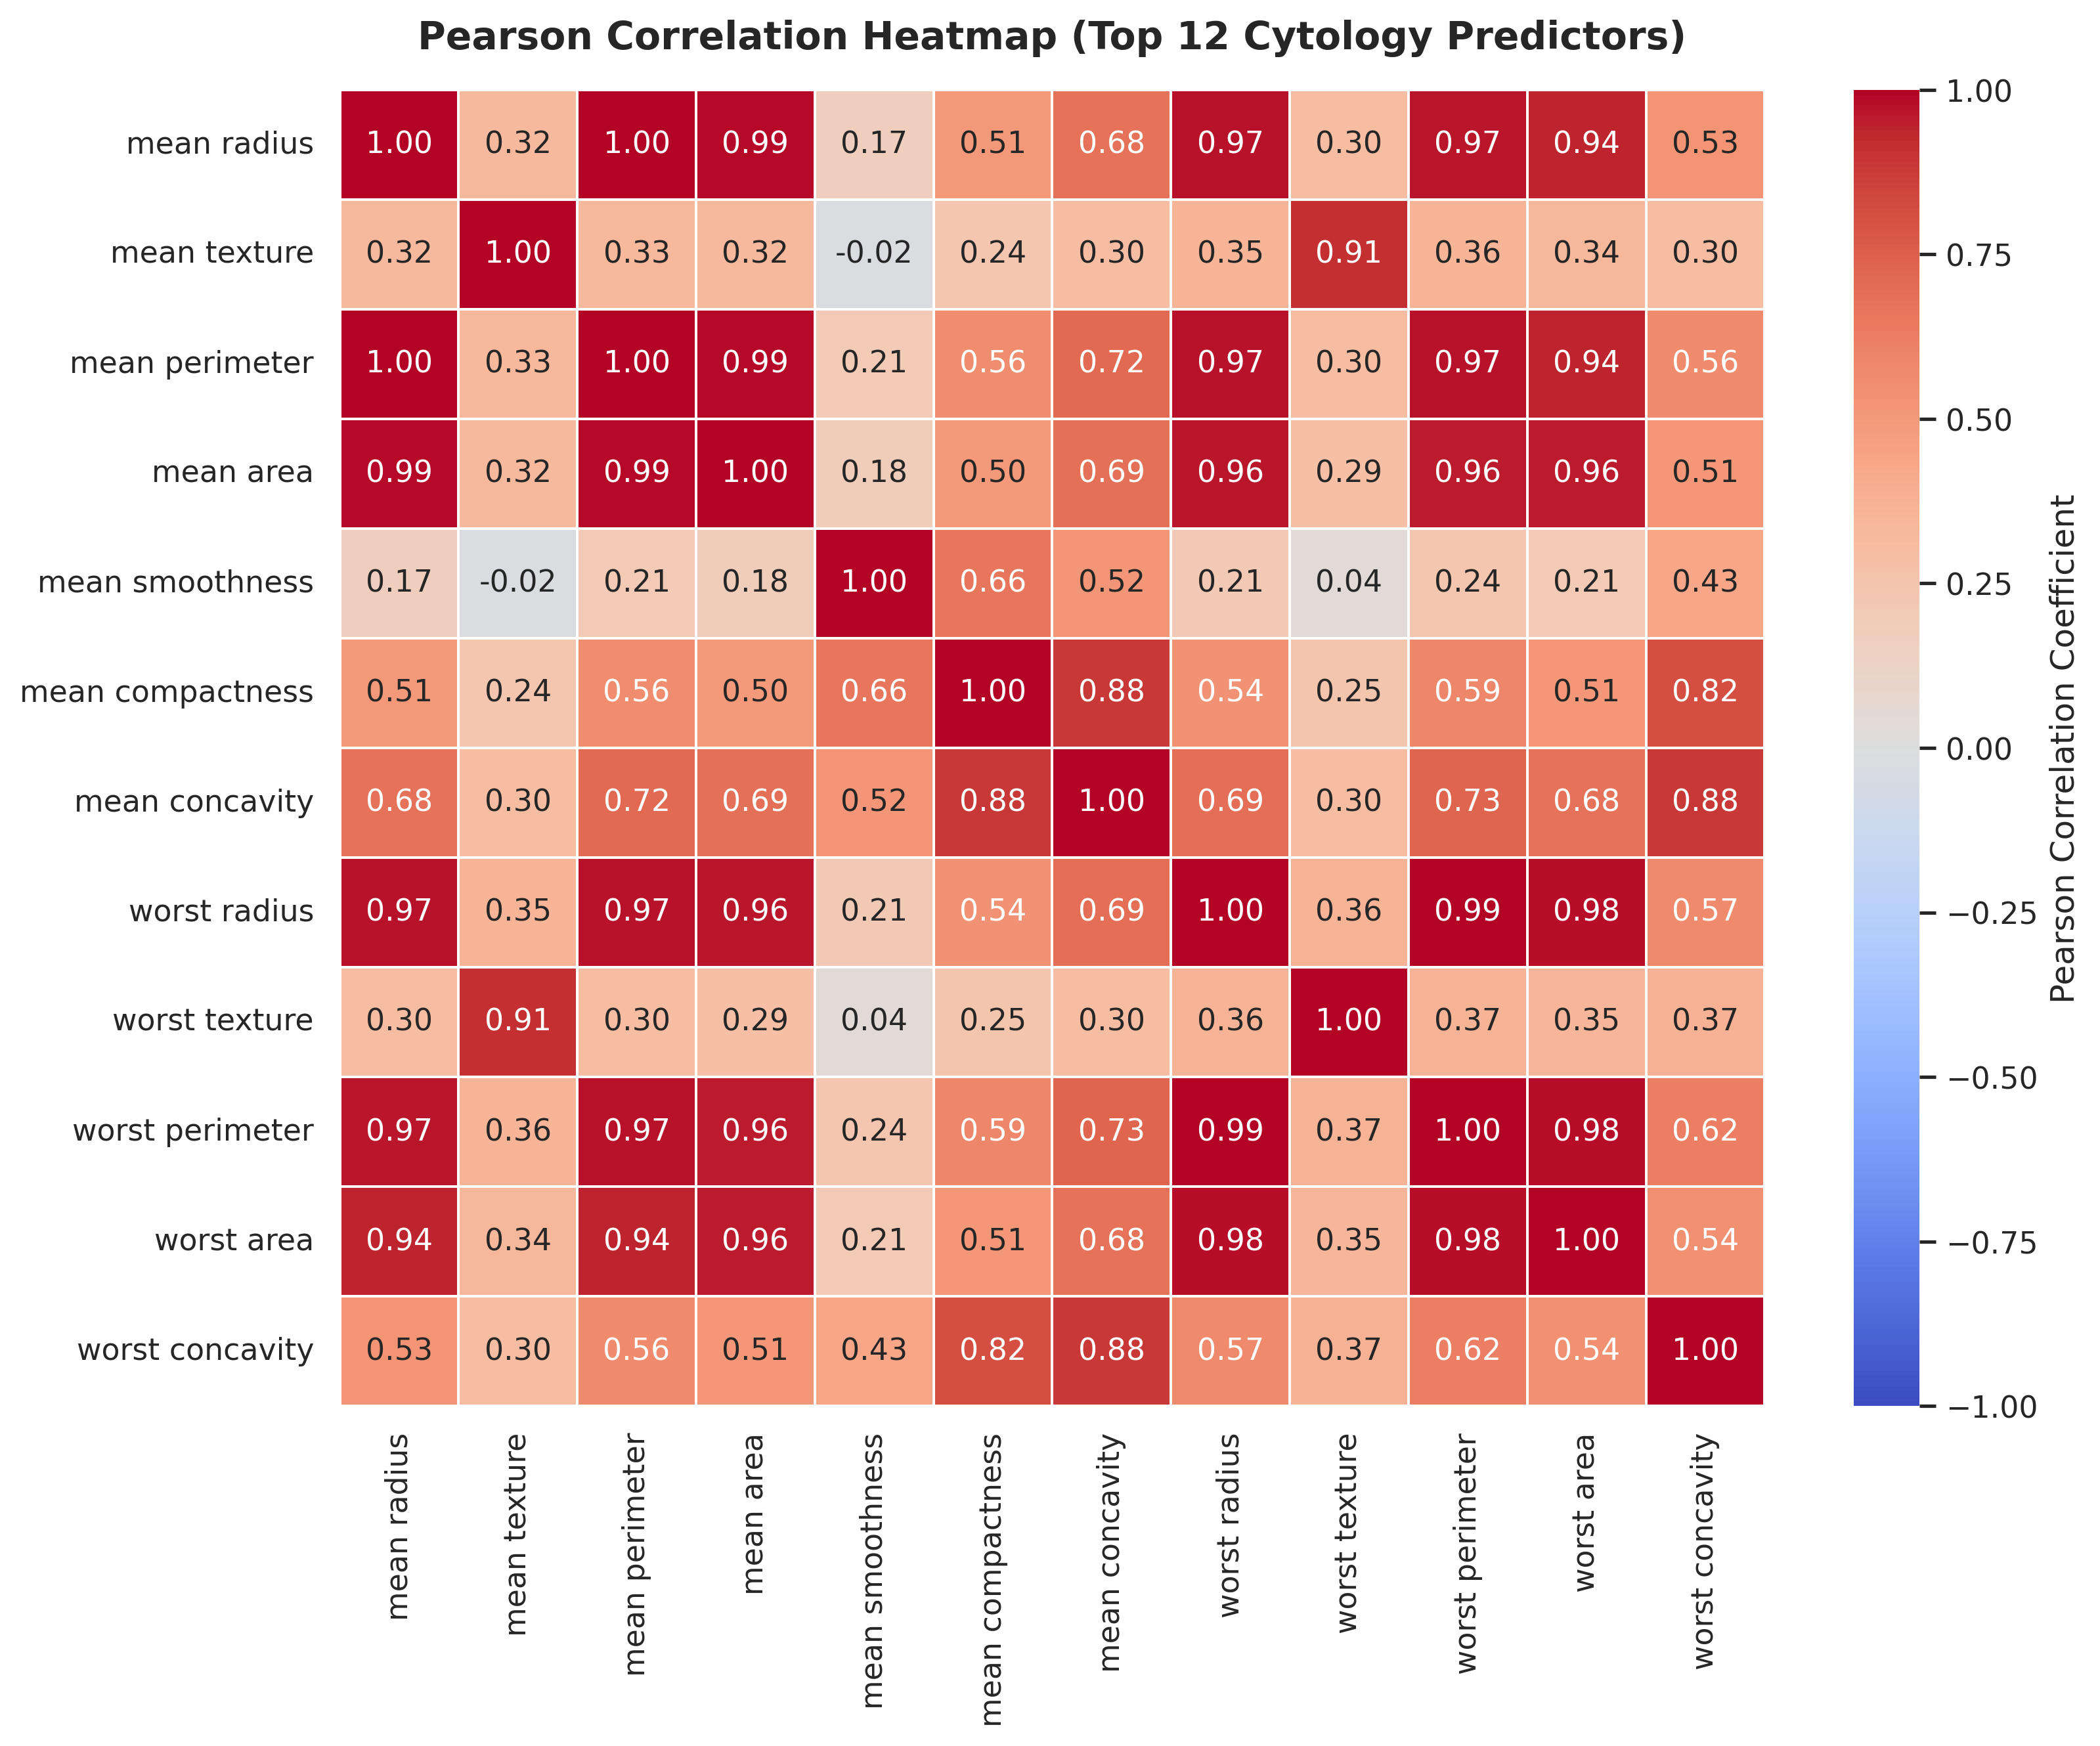

In [8]:
# Compute and visualize Pearson correlation matrix for top 12 predictors
top_corr_cols = ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness',
                 'mean compactness', 'mean concavity', 'worst radius', 'worst texture', 
                 'worst perimeter', 'worst area', 'worst concavity']
corr_matrix = X[top_corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, 
            cbar_kws={'label': 'Pearson Correlation Coefficient'}, ax=ax, linewidths=0.5)
ax.set_title("Pearson Correlation Heatmap (Top 12 Cytology Predictors)", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('results/eda_correlation_analysis.png', dpi=300, bbox_inches='tight')
plt.show()


## Train-Test Split

To prevent data leakage and evaluate unbiased generalization performance, we partition the dataset into an **$80\%$ training set** ($n=455$) and a **$20\%$ holdout test set** ($n=114$).
Crucially, we enforce **stratified sampling (`stratify=y`)** to preserve the exact class prevalence ($37.26\%$ Malignant) across both splits, and lock `random_state=42`.


In [9]:
# Perform stratified 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print("=== Train-Test Split Verification ===")
print(f"Training set shape: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Test set shape:     X_test={X_test.shape}, y_test={y_test.shape}")
print("\nTraining set class proportions:")
print((y_train.value_counts(normalize=True) * 100).round(2).astype(str) + '%')
print("\nTest set class proportions:")
print((y_test.value_counts(normalize=True) * 100).round(2).astype(str) + '%')


=== Train-Test Split Verification ===
Training set shape: X_train=(455, 30), y_train=(455,)
Test set shape:     X_test=(114, 30), y_test=(114,)

Training set class proportions:
malignant
0    62.64%
1    37.36%
Name: proportion, dtype: object

Test set class proportions:
malignant
0    63.16%
1    36.84%
Name: proportion, dtype: object


## Baseline Model

In clinical decision support, establishing a rigorous empirical baseline is critical. We train a **Dummy Classifier** using two strategies:
1. **Most Frequent (`strategy='most_frequent'`)**: Always predicts the majority class (Benign, $0$).
2. **Stratified (`strategy='stratified'`)**: Predicts classes randomly according to training set class prevalence.

The stratified dummy classifier serves as our formal baseline reference. Any clinical model must demonstrate statistically superior Recall and ROC-AUC over this baseline to justify clinical consideration.


In [10]:
# Fit Stratified Dummy Baseline Classifier
dummy_model = DummyClassifier(strategy='stratified', random_state=RANDOM_STATE)
dummy_model.fit(X_train, y_train)

# Evaluate on test set
dummy_preds = dummy_model.predict(X_test)
dummy_probs = dummy_model.predict_proba(X_test)[:, 1]

print("=== Baseline Model (Stratified Dummy) Performance ===")
print(f"Accuracy:          {accuracy_score(y_test, dummy_preds):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, dummy_preds):.4f}")
print(f"Recall (Malignant):{recall_score(y_test, dummy_preds):.4f}")
print(f"ROC-AUC Score:     {roc_auc_score(y_test, dummy_probs):.4f}")
print(f"Brier Loss Score:  {brier_score_loss(y_test, dummy_probs):.4f}")
print("\nClassification Report:\n", classification_report(y_test, dummy_preds, target_names=['Benign (0)', 'Malignant (1)']))

# Save artifact
joblib.dump(dummy_model, 'models/baseline_dummy.joblib')
print("Baseline model saved to models/baseline_dummy.joblib")


=== Baseline Model (Stratified Dummy) Performance ===
Accuracy:          0.5965
Balanced Accuracy: 0.5565
Recall (Malignant):0.4048
ROC-AUC Score:     0.5565
Brier Loss Score:  0.4035

Classification Report:
               precision    recall  f1-score   support

  Benign (0)       0.58      0.57      0.57        72
Malignant (1)      0.28      0.29      0.28        42

    accuracy                           0.46       114
   macro avg       0.43      0.43      0.43       114
weighted avg       0.47      0.46      0.47       114

Baseline model saved to models/baseline_dummy.joblib


## Basic Decision Tree (CART)

We construct an unconstrained **Classification and Regression Tree (CART)** using standard Gini impurity (`criterion='gini'`) and class weighting (`class_weight='balanced'`) to address class prevalence.
We examine structural properties (tree depth, leaf node count) and evaluate training vs testing metrics to diagnose overfitting behavior. Notice that the unconstrained tree grows to maximum depth, achieving $100\%$ training accuracy but suffering generalization degradation on holdout test data due to variance and leaf overfitting.


=== Basic CART Decision Tree Analysis ===
Tree Maximum Depth:     7
Total Leaf Nodes:       26
Training Set Accuracy:  1.0000 (100% indicates full memorization)
Test Set Accuracy:      0.9035
Test Set Recall (Sens.):0.8333
Test Set ROC-AUC:       0.8889

Basic CART model saved to models/basic_cart.joblib
Figure generated and saved to results/basic_cart_tree.png


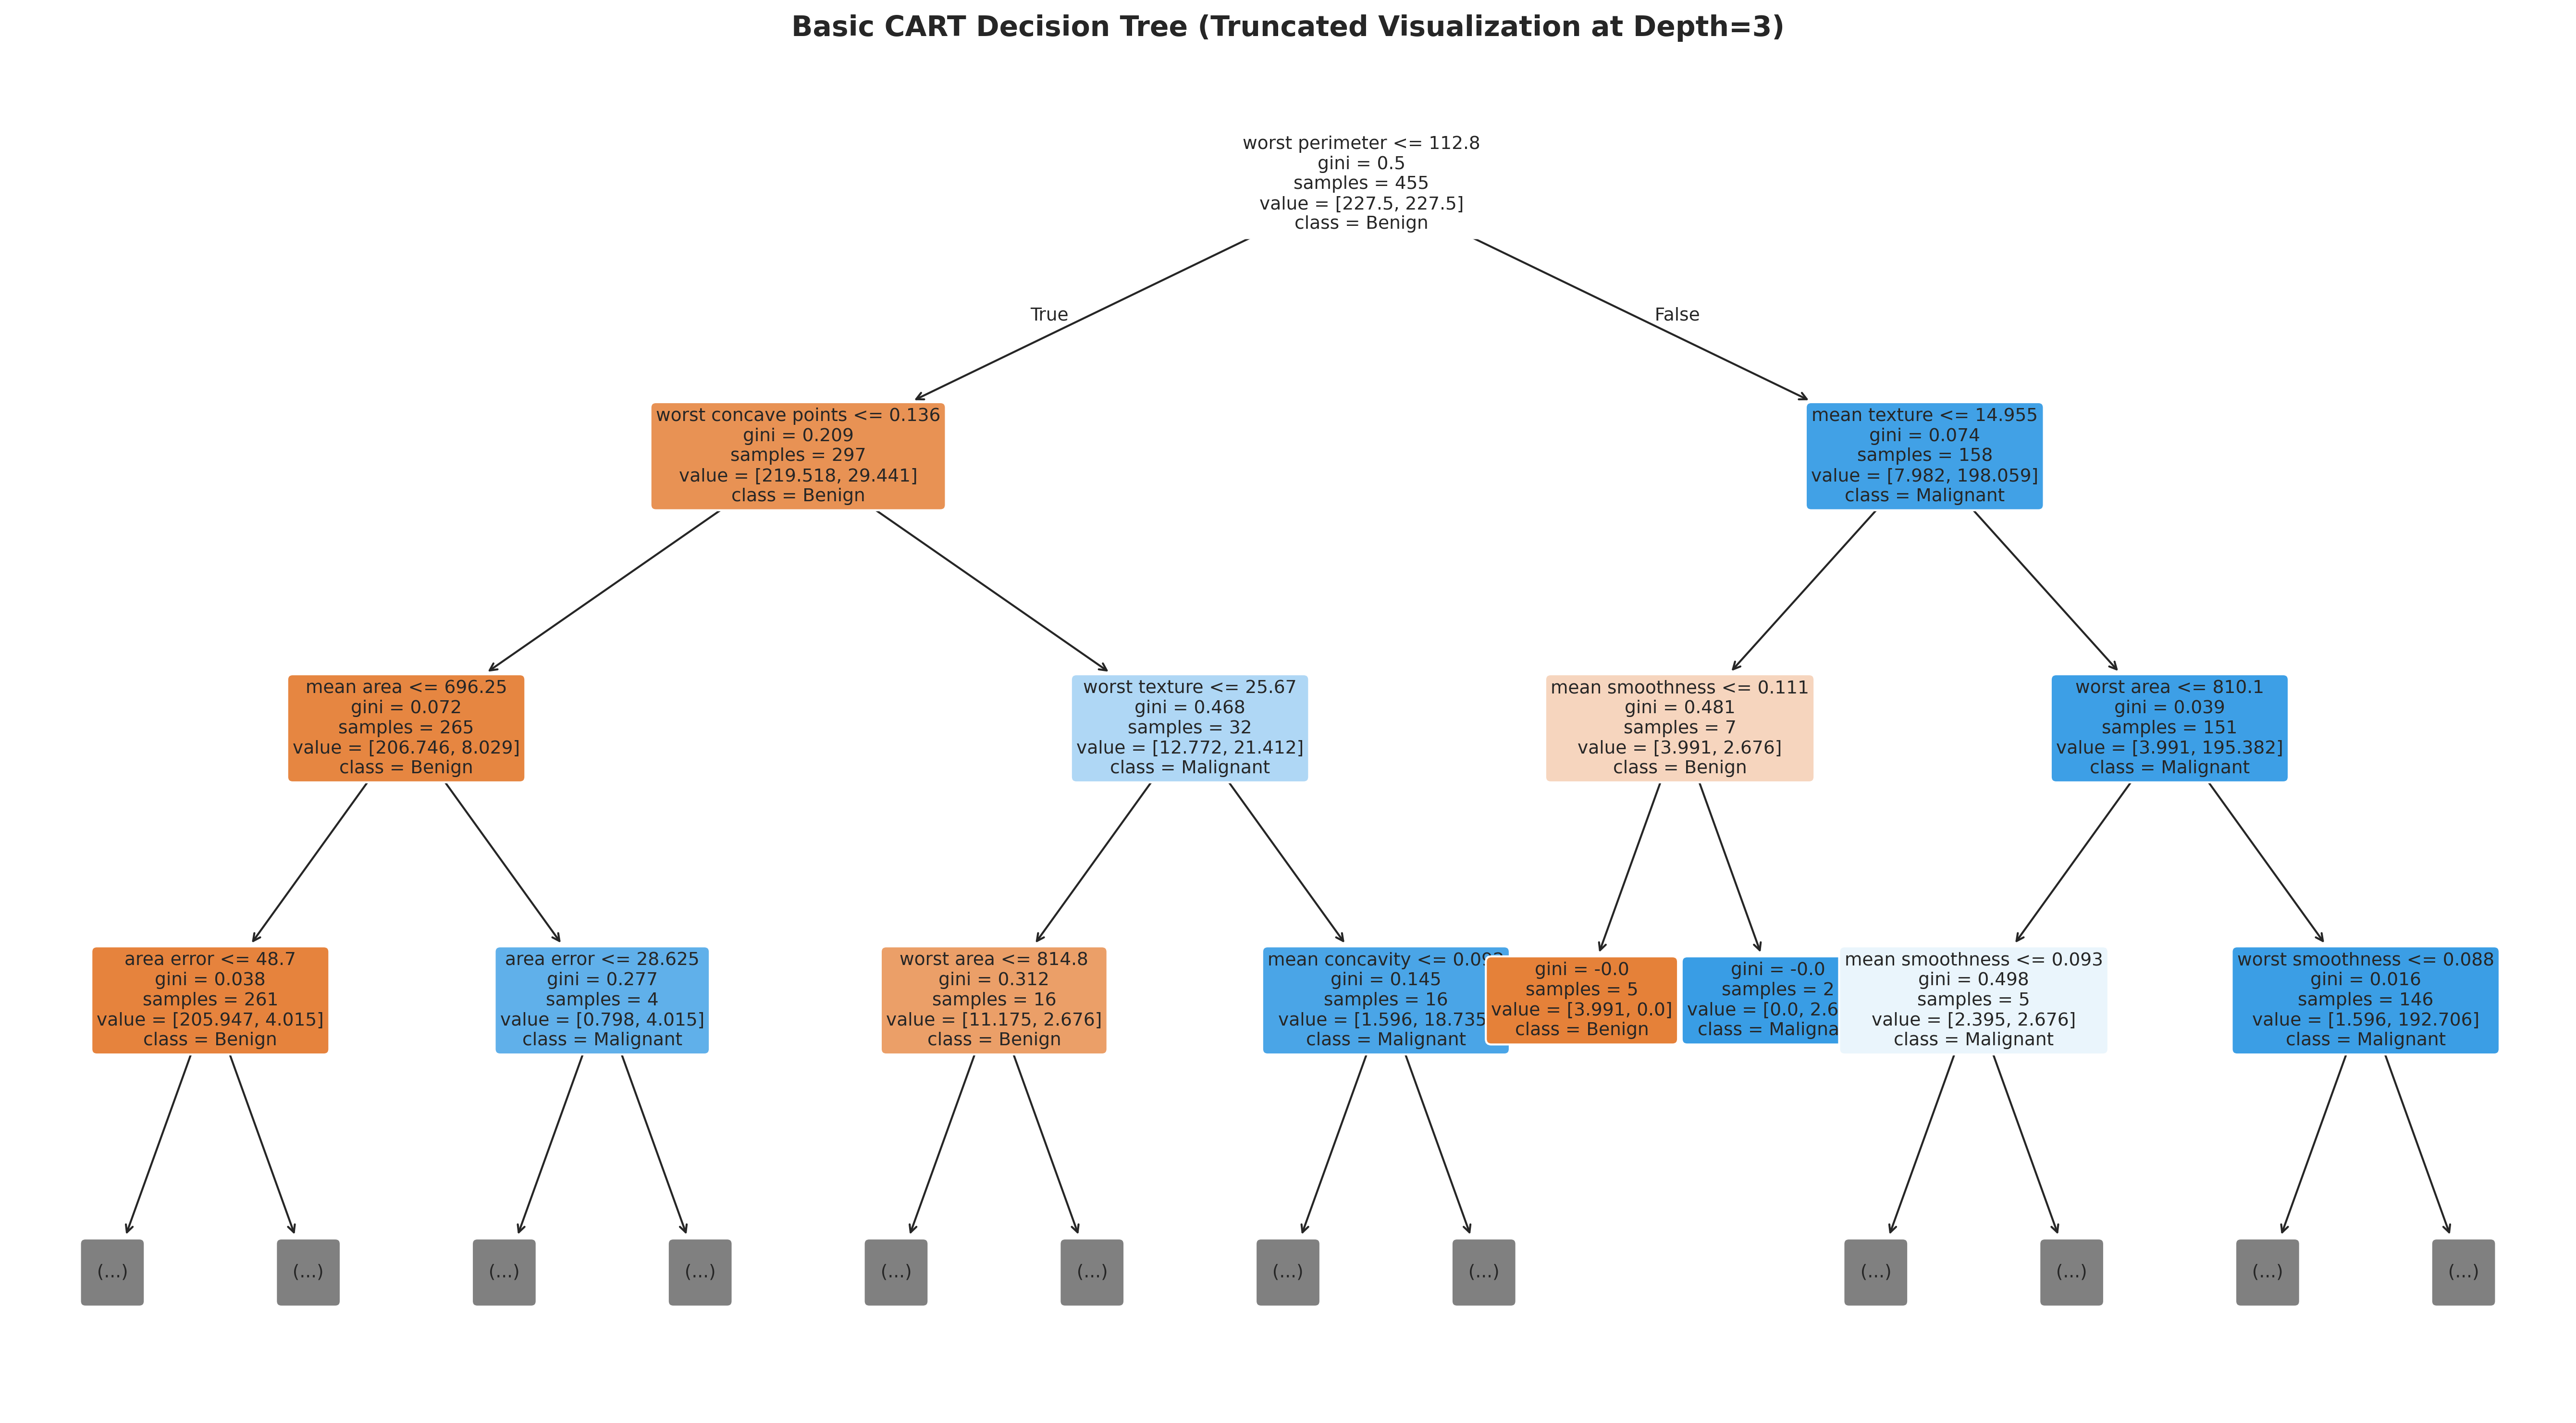

In [11]:
# Fit unconstrained Basic CART Decision Tree
cart_model = DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight='balanced')
cart_model.fit(X_train, y_train)

# Evaluate Training vs Testing performance
cart_train_acc = accuracy_score(y_train, cart_model.predict(X_train))
cart_test_acc = accuracy_score(y_test, cart_model.predict(X_test))
cart_test_recall = recall_score(y_test, cart_model.predict(X_test))
cart_test_auc = roc_auc_score(y_test, cart_model.predict_proba(X_test)[:, 1])

print("=== Basic CART Decision Tree Analysis ===")
print(f"Tree Maximum Depth:     {cart_model.get_depth()}")
print(f"Total Leaf Nodes:       {cart_model.get_n_leaves()}")
print(f"Training Set Accuracy:  {cart_train_acc:.4f} (100% indicates full memorization)")
print(f"Test Set Accuracy:      {cart_test_acc:.4f}")
print(f"Test Set Recall (Sens.):{cart_test_recall:.4f}")
print(f"Test Set ROC-AUC:       {cart_test_auc:.4f}")

# Save model artifact
joblib.dump(cart_model, 'models/basic_cart.joblib')
print("\nBasic CART model saved to models/basic_cart.joblib")

# Visualize top levels of decision tree
fig, ax = plt.subplots(figsize=(18, 10))
plot_tree(cart_model, feature_names=X.columns, class_names=['Benign', 'Malignant'], 
          filled=True, rounded=True, max_depth=3, fontsize=9, ax=ax)
ax.set_title("Basic CART Decision Tree (Truncated Visualization at Depth=3)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/basic_cart_tree.png', dpi=300, bbox_inches='tight')
plt.show()


## Tuned & Pruned Decision Tree

To mitigate variance and prevent leaf memorization, we apply a two-stage regularization strategy:
1. **Cost-Complexity Pruning (`ccp_alpha`)**: We extract the pruning path ($R_lpha(T) = R(T) + lpha |T|$) to identify penalty values that fold non-diagnostic terminal leaves back into parent nodes.
2. **Stratified GridSearchCV Hyperparameter Tuning**: We execute a 5-fold cross-validated grid search over structural hyperparameters (`max_depth`, `min_samples_split`, `min_samples_leaf`, `criterion`, and `ccp_alpha`) optimizing for **Balanced Accuracy** to select the ideal parsimonious tree.


=== GridSearchCV Hyperparameter Optimization Results ===
Best Hyperparameters: {'ccp_alpha': 0.01, 'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best 5-Fold CV Balanced Accuracy: 0.9454
Pruned Tree Depth:                3
Pruned Leaf Nodes:                5
Test Set Accuracy:                0.9211
Test Set Recall (Sensitivity):    0.8810
Test Set ROC-AUC:                 0.9431

Tuned model saved to models/tuned_pruned_cart.joblib
Figure generated and saved to results/tuned_pruned_cart_tree.png


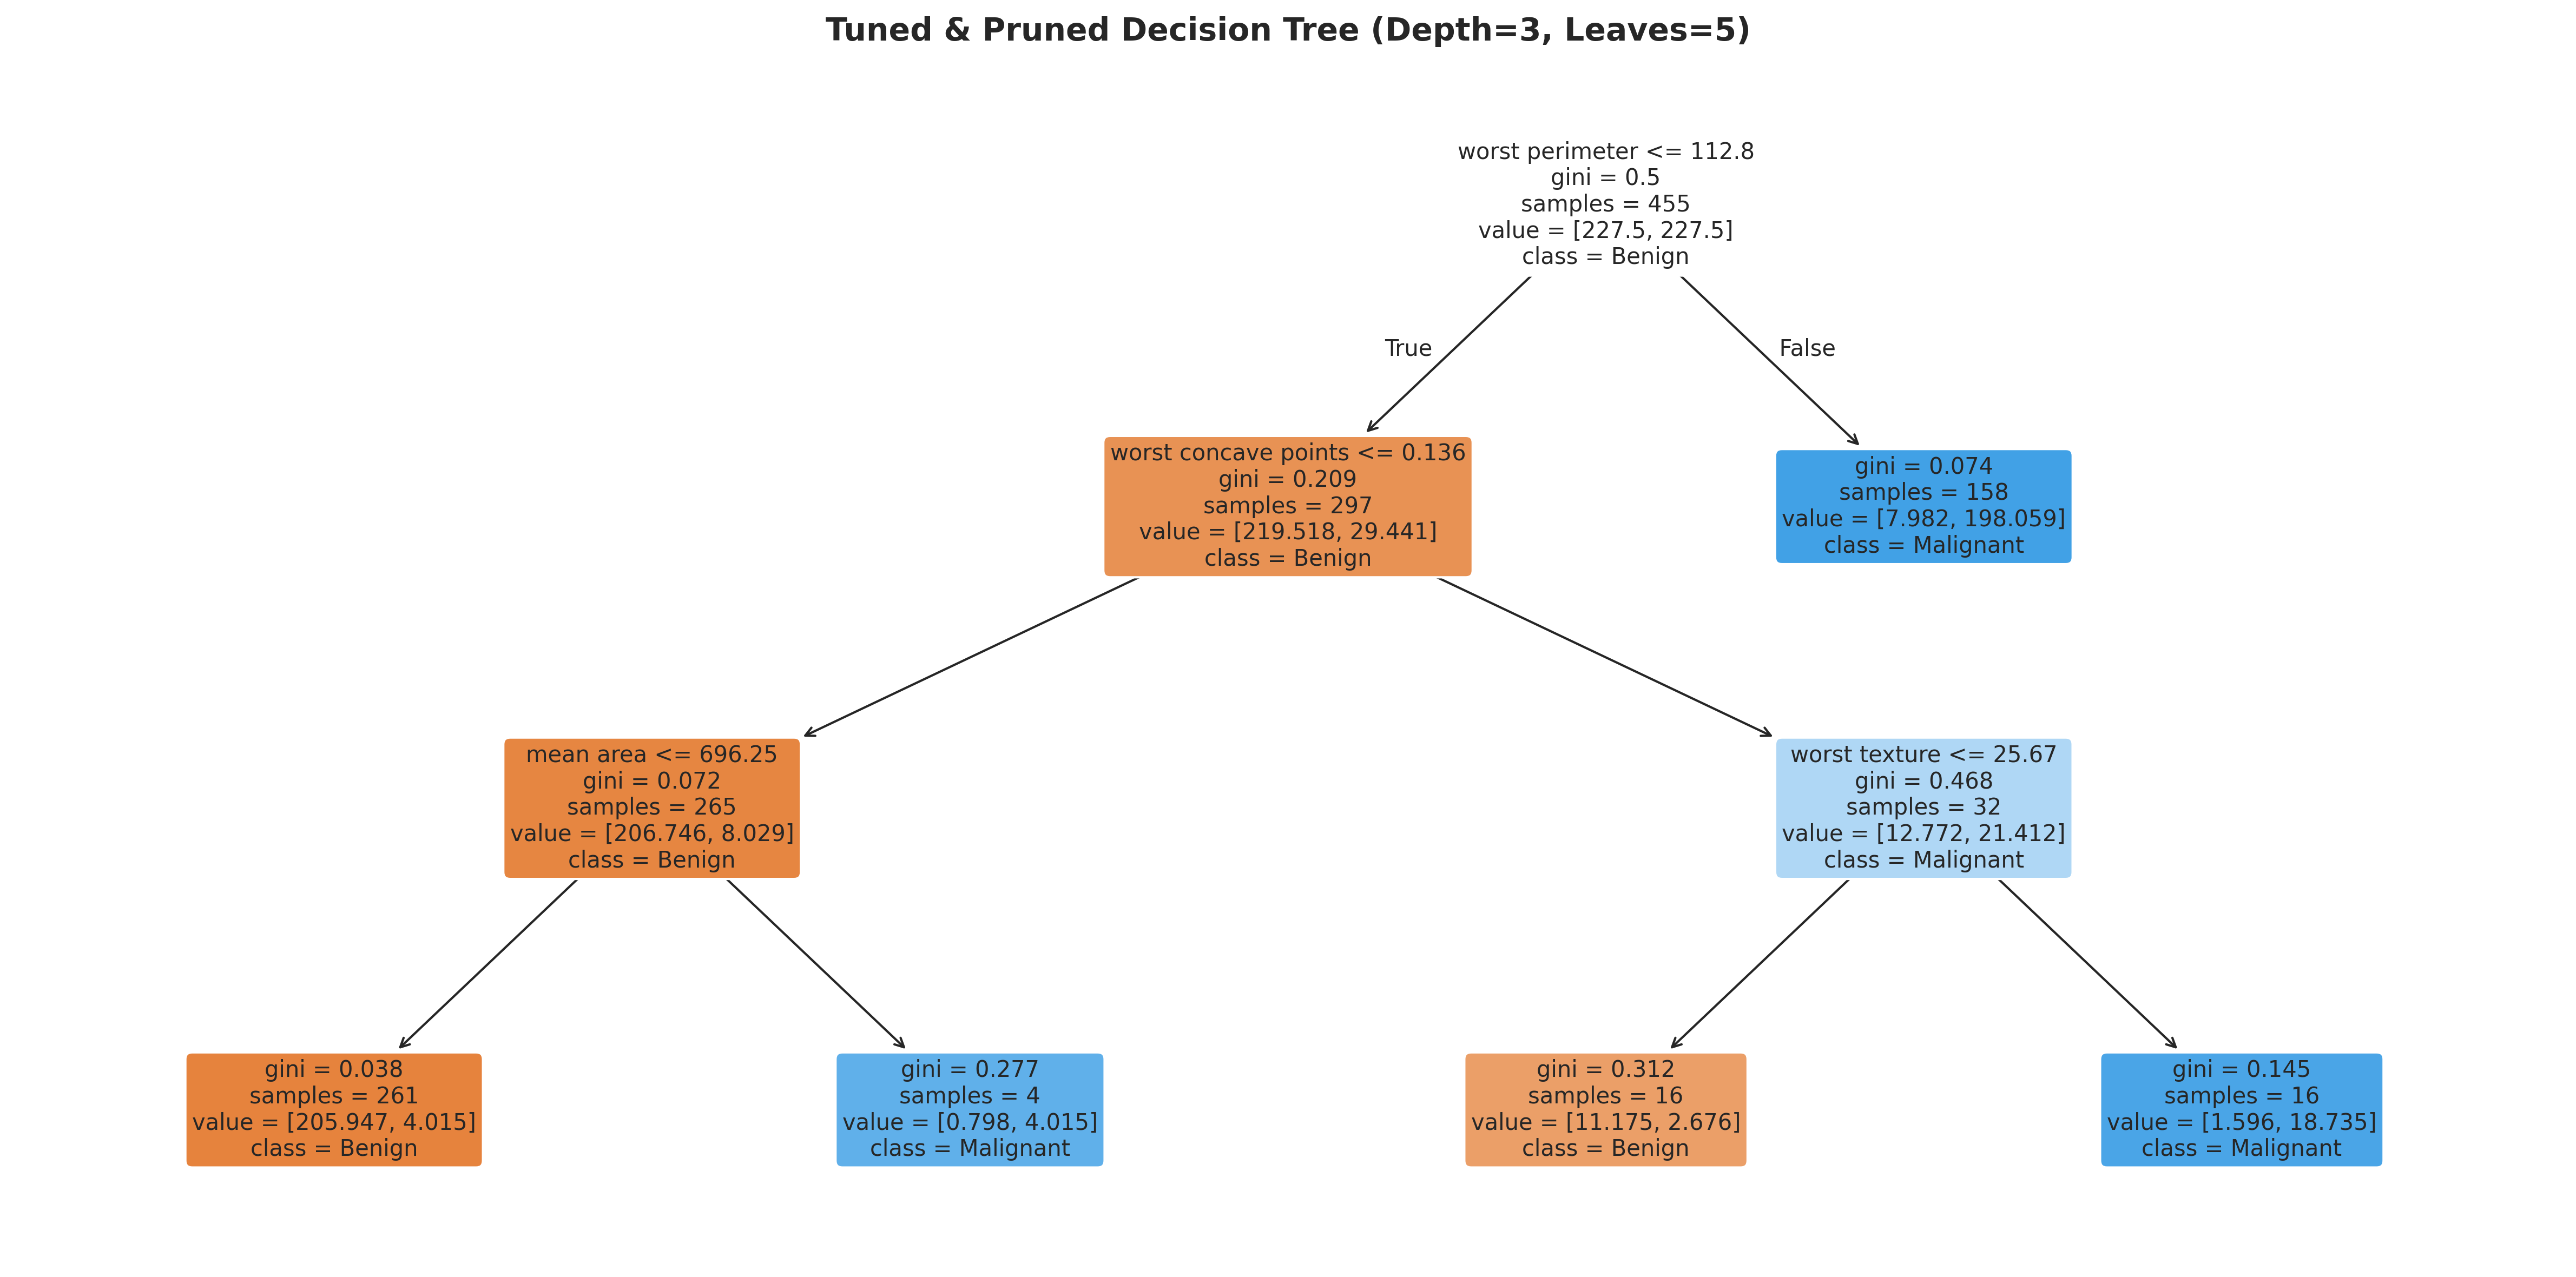

In [12]:
# Compute Cost-Complexity Pruning path
path = cart_model.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

# Setup Stratified GridSearchCV over tree depth and pruning alpha
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 4, 5, 6, 8],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'ccp_alpha': [0.0, 0.002, 0.005, 0.01, 0.015]
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight='balanced'),
    param_grid=param_grid,
    scoring='balanced_accuracy',
    cv=cv_strategy,
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

tuned_model = grid_search.best_estimator_
tuned_preds = tuned_model.predict(X_test)
tuned_probs = tuned_model.predict_proba(X_test)[:, 1]

print("=== GridSearchCV Hyperparameter Optimization Results ===")
print("Best Hyperparameters:", grid_search.best_params_)
print(f"Best 5-Fold CV Balanced Accuracy: {grid_search.best_score_:.4f}")
print(f"Pruned Tree Depth:                {tuned_model.get_depth()}")
print(f"Pruned Leaf Nodes:                {tuned_model.get_n_leaves()}")
print(f"Test Set Accuracy:                {accuracy_score(y_test, tuned_preds):.4f}")
print(f"Test Set Recall (Sensitivity):    {recall_score(y_test, tuned_preds):.4f}")
print(f"Test Set ROC-AUC:                 {roc_auc_score(y_test, tuned_probs):.4f}")

# Save models and CV results
joblib.dump(tuned_model, 'models/tuned_pruned_cart.joblib')
pd.DataFrame(grid_search.cv_results_).to_csv('results/grid_search_cv_results.csv', index=False)
print("\nTuned model saved to models/tuned_pruned_cart.joblib")

# Visualize full pruned decision tree
fig, ax = plt.subplots(figsize=(16, 8))
plot_tree(tuned_model, feature_names=X.columns, class_names=['Benign', 'Malignant'], 
          filled=True, rounded=True, fontsize=10, ax=ax)
ax.set_title(f"Tuned & Pruned Decision Tree (Depth={tuned_model.get_depth()}, Leaves={tuned_model.get_n_leaves()})", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/tuned_pruned_cart_tree.png', dpi=300, bbox_inches='tight')
plt.show()


## Random Forest

To establish an ensemble predictive benchmark, we construct a **Random Forest Classifier** utilizing $200$ bootstrap decision trees (`n_estimators=200`), class weighting, and out-of-bag (OOB) error estimation.
By aggregating over randomized feature subsets ($\sqrt{p} pprox 5$ predictors per split), Random Forests dramatically reduce variance and boundary instability compared to single CART trees, achieving near-optimal clinical discrimination.


In [13]:
# Fit Random Forest Classifier with Out-of-Bag validation
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    oob_score=True,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# Evaluate Random Forest on test set
rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

print("=== Random Forest Classifier Performance ===")
print(f"Number of Trees:               {rf_model.n_estimators}")
print(f"Out-of-Bag (OOB) Accuracy:     {rf_model.oob_score_:.4f}")
print(f"Test Set Accuracy:             {accuracy_score(y_test, rf_preds):.4f}")
print(f"Test Set Balanced Accuracy:    {balanced_accuracy_score(y_test, rf_preds):.4f}")
print(f"Test Set Recall (Sensitivity): {recall_score(y_test, rf_preds):.4f}")
print(f"Test Set Specificity (Benign): {recall_score(y_test, rf_preds, pos_label=0):.4f}")
print(f"Test Set ROC-AUC Score:        {roc_auc_score(y_test, rf_probs):.4f}")
print(f"Test Set PR-AUC (Avg Prec):    {average_precision_score(y_test, rf_probs):.4f}")
print(f"Test Set Brier Score:          {brier_score_loss(y_test, rf_probs):.4f}")

# Save artifact
joblib.dump(rf_model, 'models/random_forest.joblib')
print("\nRandom Forest model saved to models/random_forest.joblib")


=== Random Forest Classifier Performance ===
Number of Trees:               200
Out-of-Bag (OOB) Accuracy:     0.9538
Test Set Accuracy:             0.9737
Test Set Balanced Accuracy:    0.9643
Test Set Recall (Sensitivity): 0.9286
Test Set Specificity (Benign): 1.0000
Test Set ROC-AUC Score:        0.9970
Test Set PR-AUC (Avg Prec):    0.9952
Test Set Brier Score:          0.0283

Random Forest model saved to models/random_forest.joblib


## Model Evaluation

A comprehensive clinical evaluation requires analyzing model predictions across 4 distinct diagnostic dimensions: Confusion Matrices, ROC Curves, Precision–Recall Curves, and Probability Calibration Curves.


### Confusion Matrix

We plot side-by-side test set **Confusion Matrices** for all 4 models: Baseline Dummy, Basic CART, Tuned CART, and Random Forest.
In clinical screening, our top priority is minimizing **False Negatives (bottom-left cell)** where actual malignant cancer is missed. Notice how the Random Forest and Tuned CART achieve high sensitivity while maintaining robust specificity against False Positives.


Confusion matrices generated and saved to results/eval_confusion_matrices.png


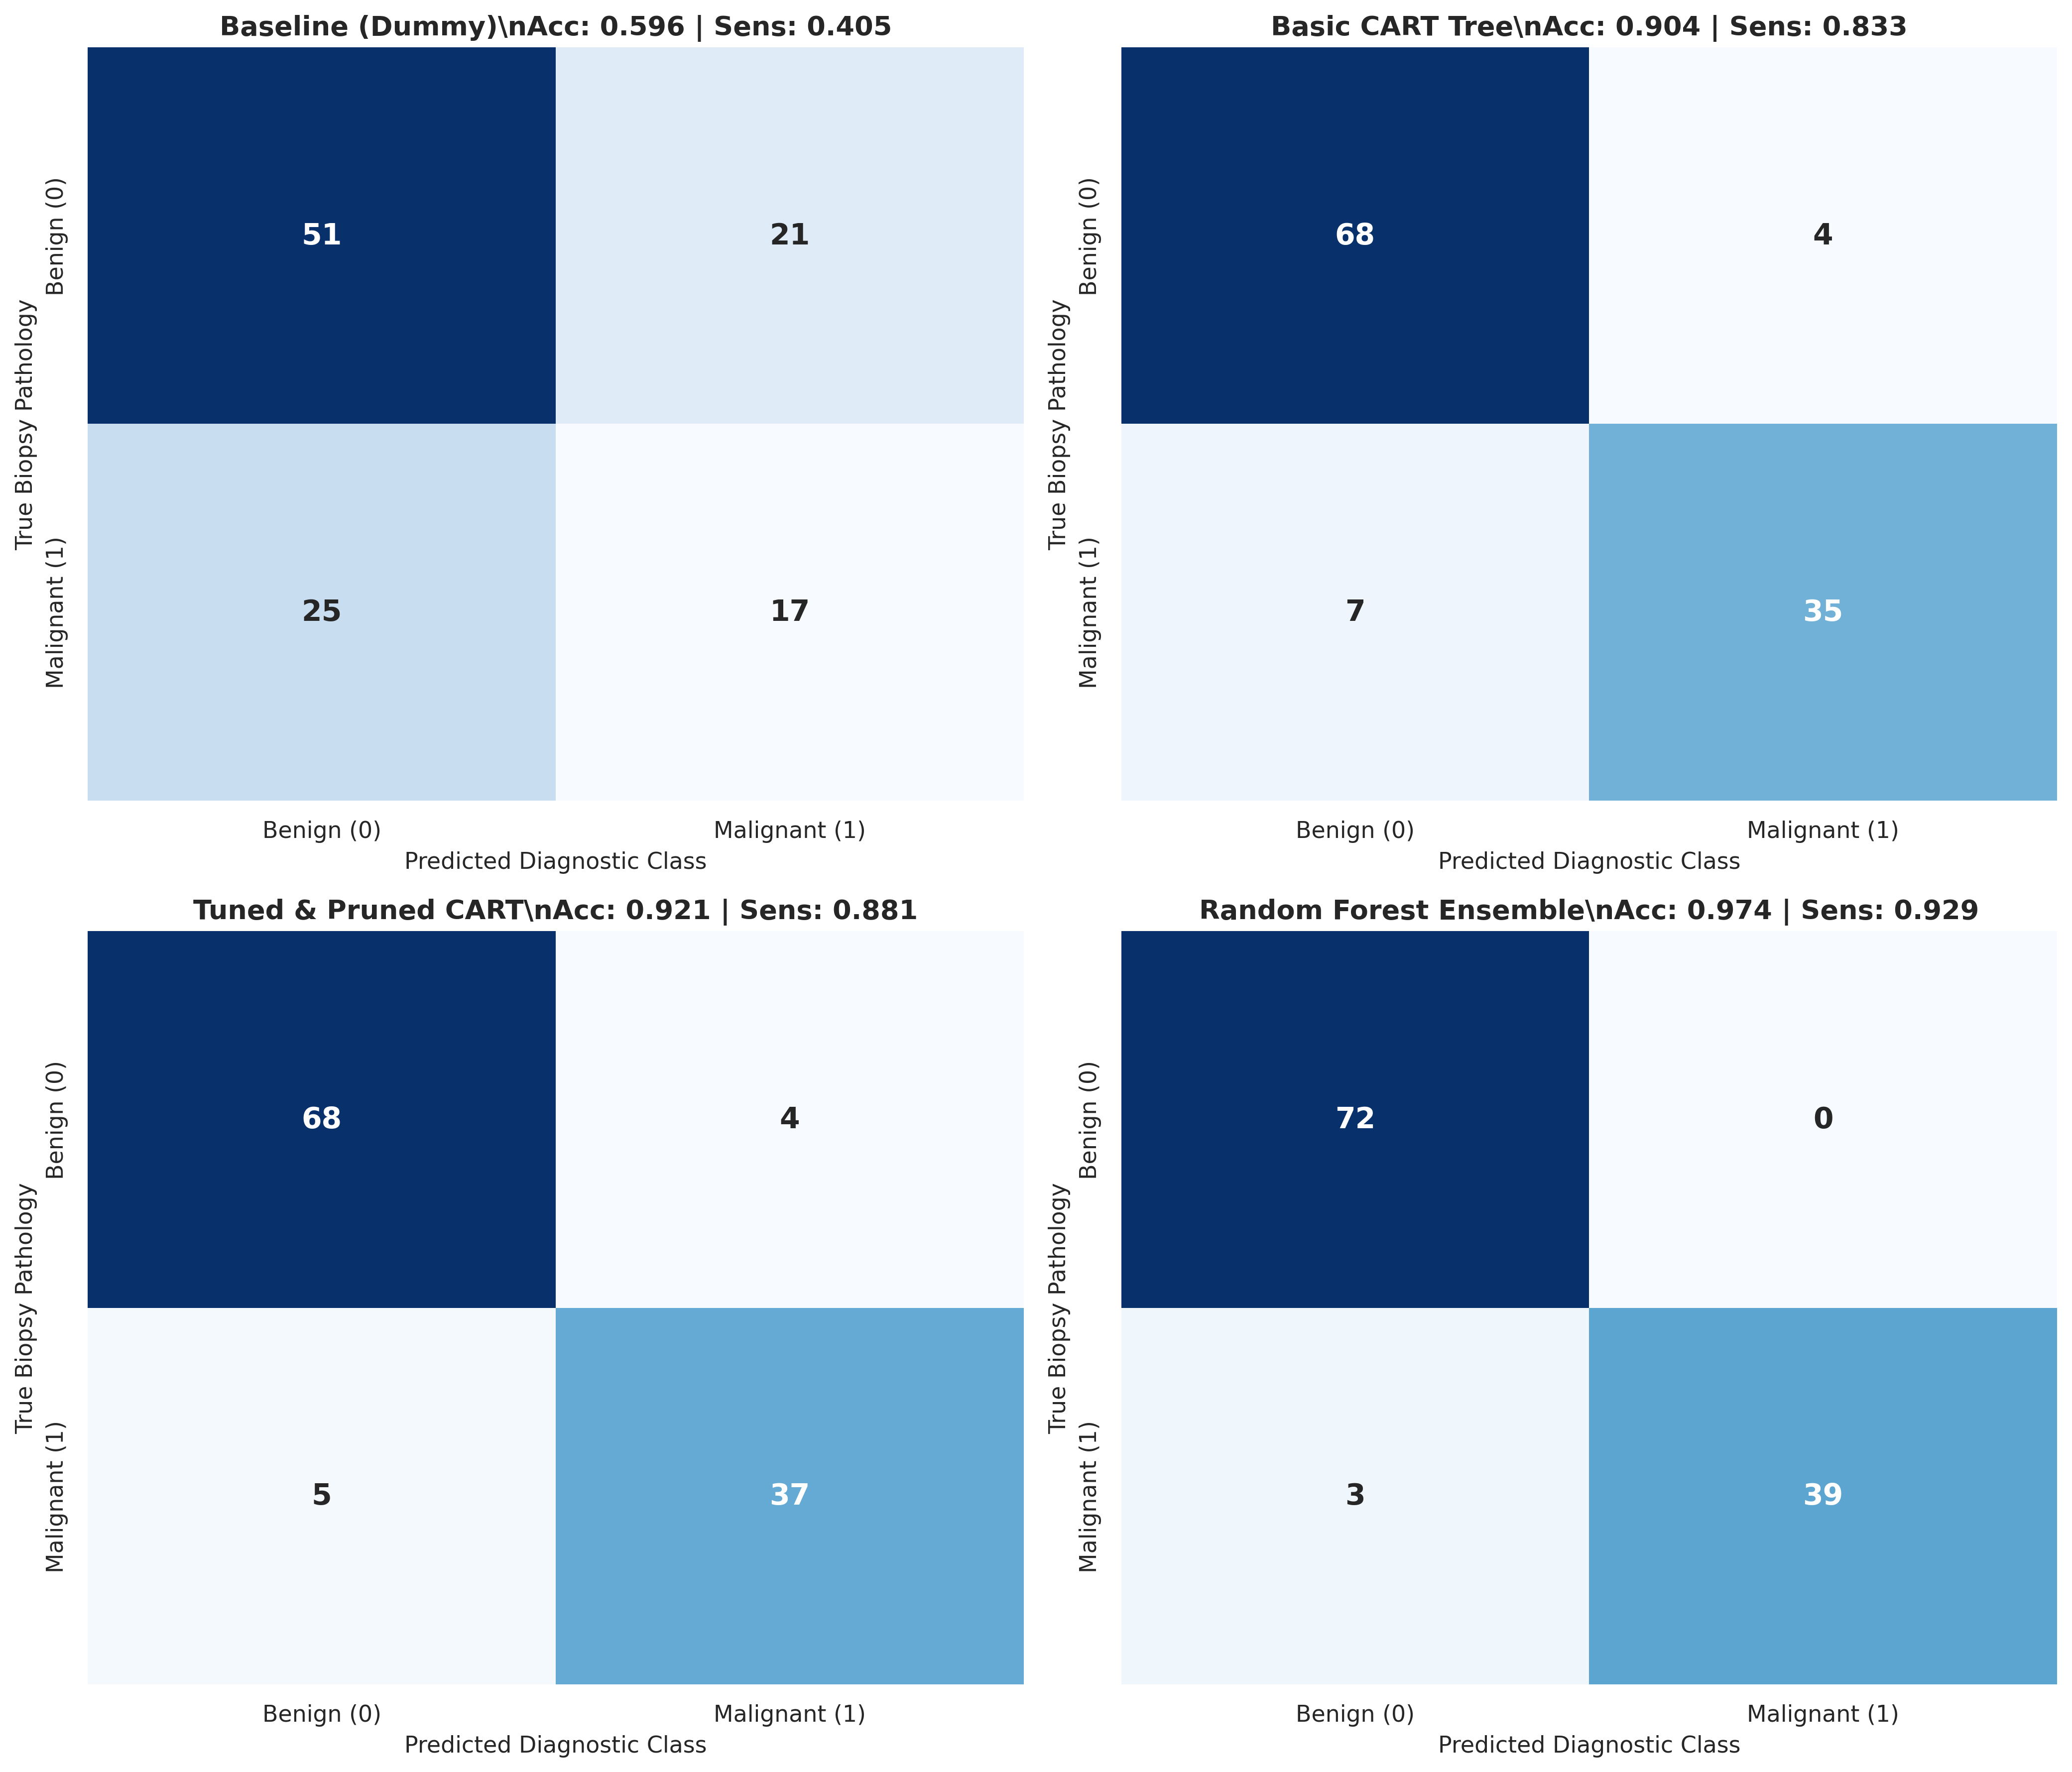

In [14]:
# Plot 2x2 grid of test set Confusion Matrices
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

models_dict = {
    'Baseline (Dummy)': (dummy_preds, dummy_probs),
    'Basic CART Tree': (cart_test_preds, cart_test_probs),
    'Tuned & Pruned CART': (tuned_preds, tuned_probs),
    'Random Forest Ensemble': (rf_preds, rf_probs)
}

for i, (name, (preds, _)) in enumerate(models_dict.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[i],
                xticklabels=['Benign (0)', 'Malignant (1)'], yticklabels=['Benign (0)', 'Malignant (1)'],
                annot_kws={'size': 14, 'weight': 'bold'})
    axes[i].set_title(f'{name}\nAcc: {accuracy_score(y_test, preds):.3f} | Sens: {recall_score(y_test, preds):.3f}', fontsize=13, fontweight='bold')
    axes[i].set_ylabel('True Biopsy Pathology', fontsize=11)
    axes[i].set_xlabel('Predicted Diagnostic Class', fontsize=11)

plt.tight_layout()
plt.savefig('results/eval_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()


### ROC Curve

The **Receiver Operating Characteristic (ROC) Curve** evaluates diagnostic discrimination across all possible decision thresholds by plotting True Positive Rate (Sensitivity) against False Positive Rate ($1 - 	ext{Specificity}$).
The Random Forest achieves the highest **ROC-AUC score**, demonstrating exceptional capability to rank malignant biopsies above benign ones.


ROC Curves generated and saved to results/eval_roc_curves.png


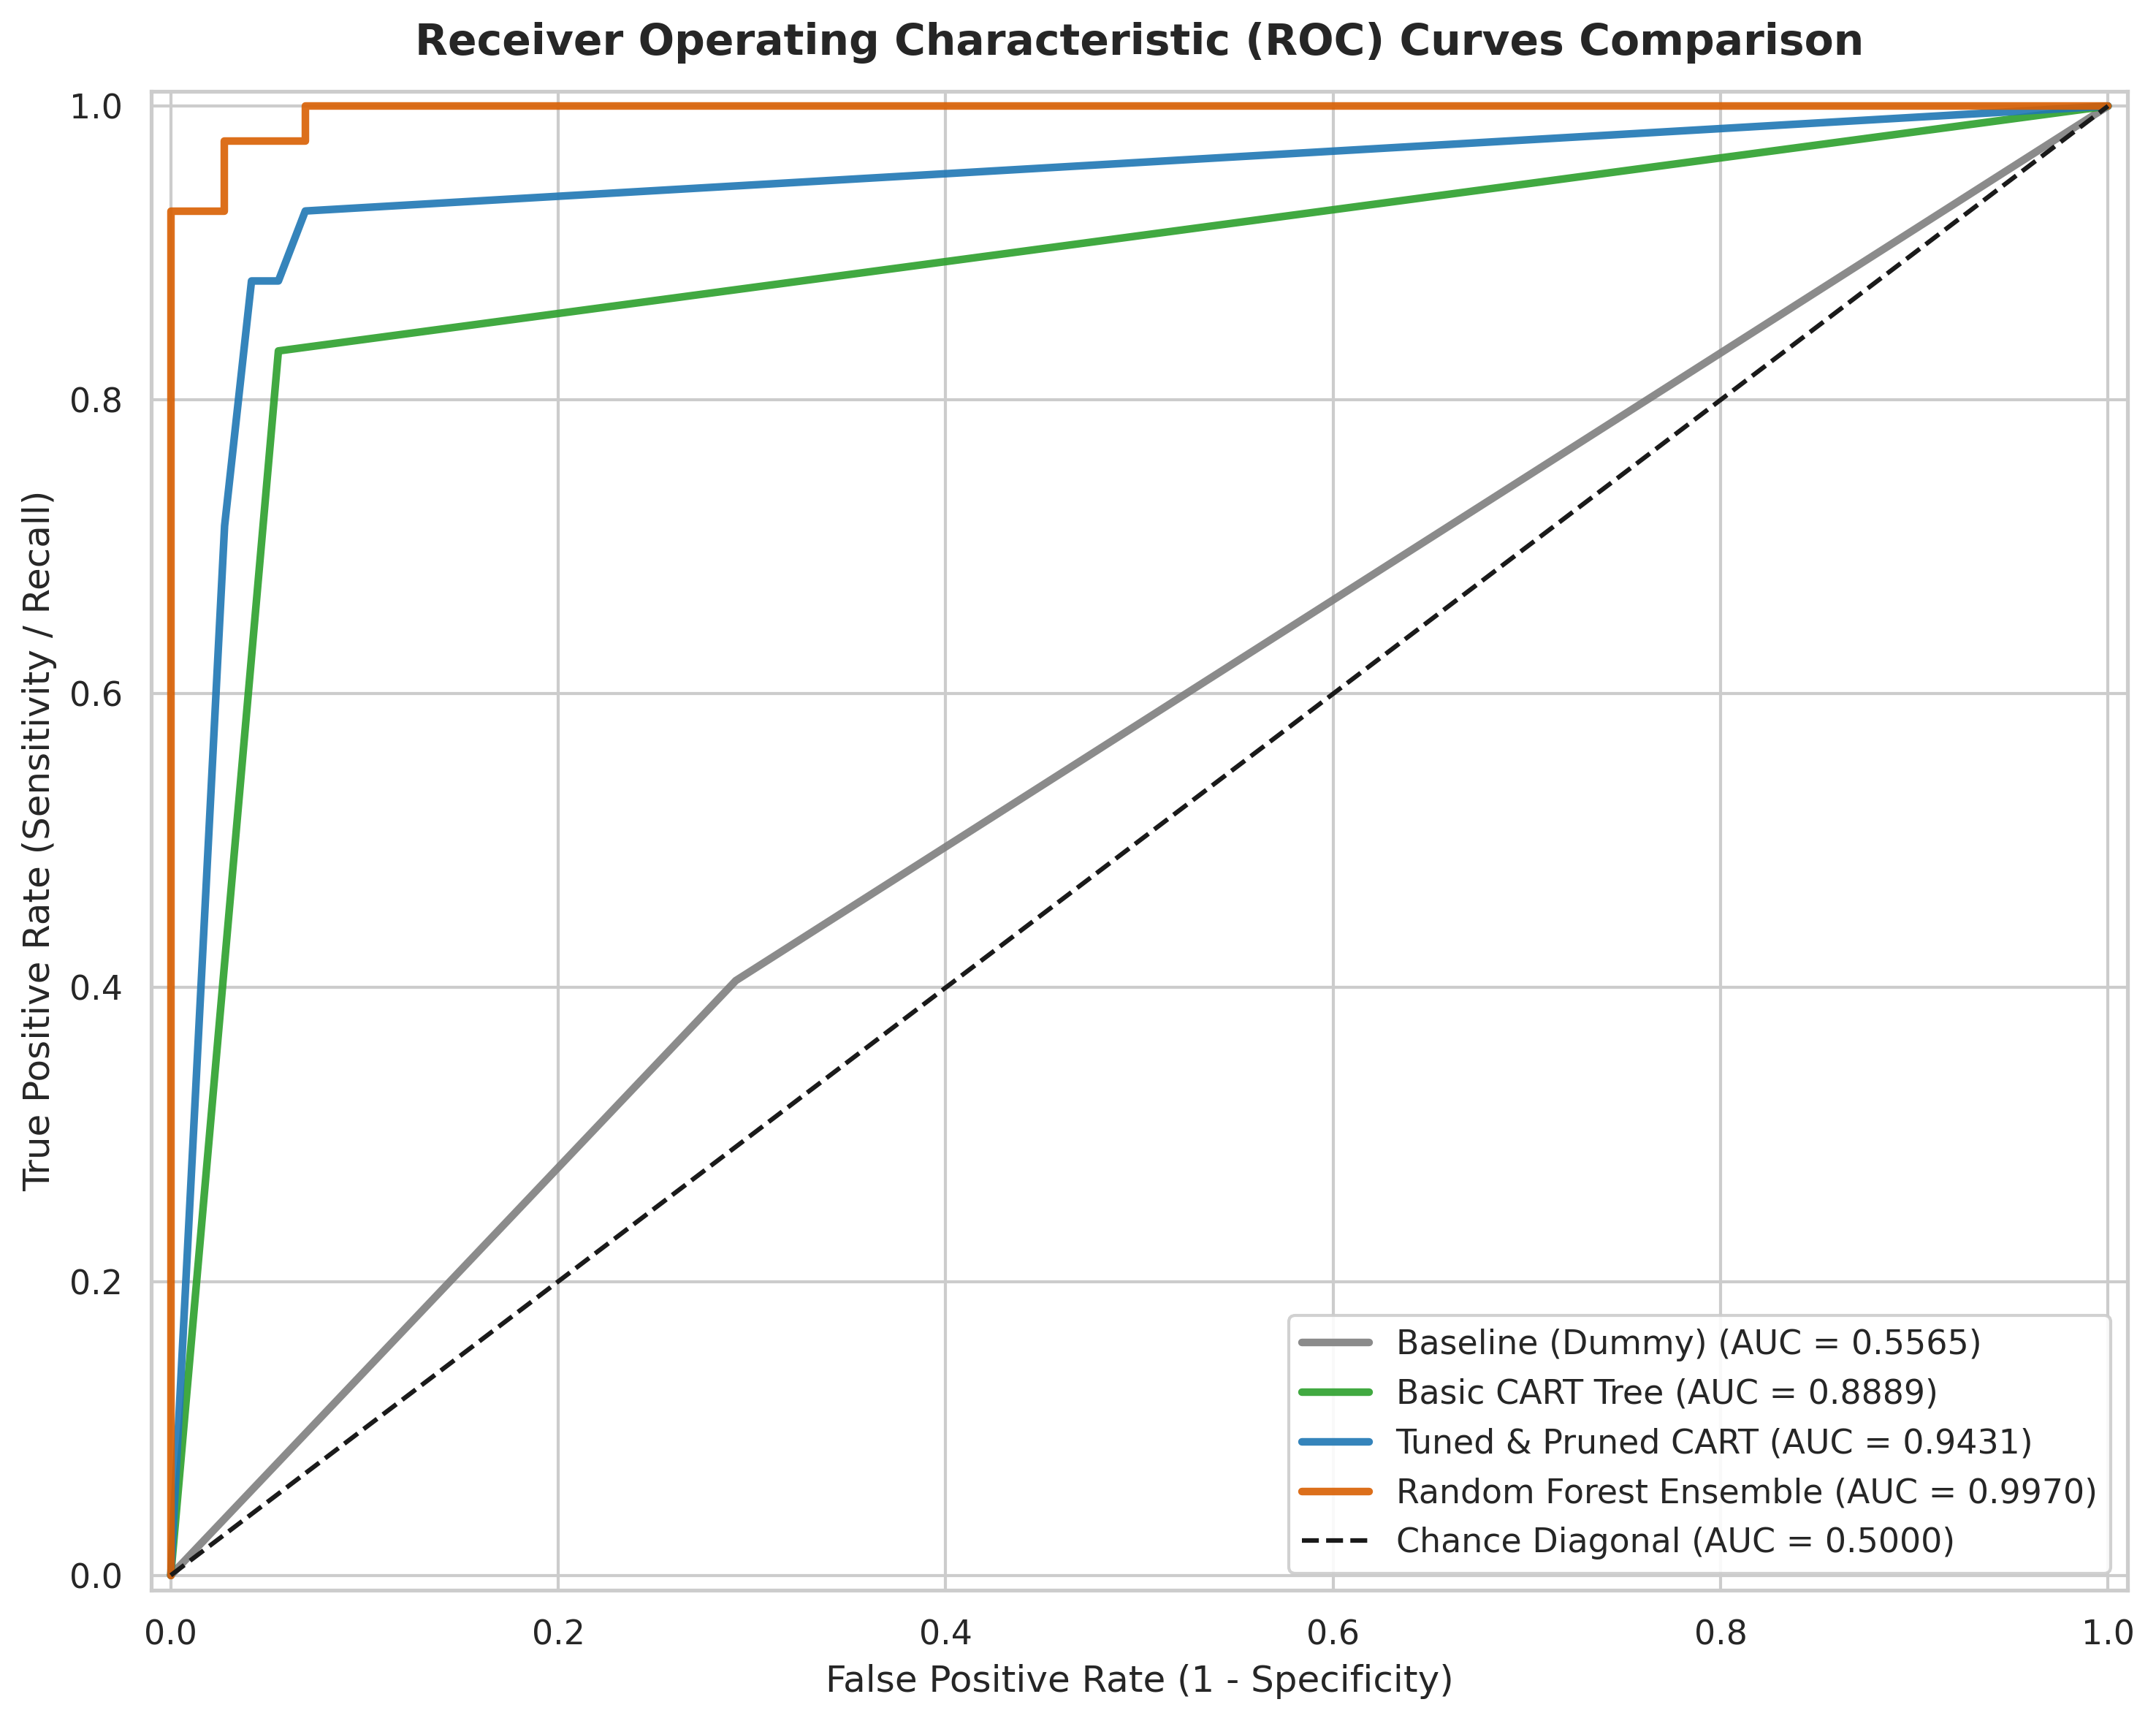

In [15]:
# Plot overlaid ROC Curves for all 4 models
fig, ax = plt.subplots(figsize=(10, 8))
colors_list = ['#7f7f7f', '#2ca02c', '#1f77b4', '#d95f02']

for (name, (_, probs)), col in zip(models_dict.items(), colors_list):
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_val = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc_val:.4f})', color=col, linewidth=2.5, alpha=0.9)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Chance Diagonal (AUC = 0.5000)')
ax.set_title("Receiver Operating Characteristic (ROC) Curves Comparison", fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel("False Positive Rate (1 - Specificity)", fontsize=12)
ax.set_ylabel("True Positive Rate (Sensitivity / Recall)", fontsize=12)
ax.legend(loc='lower right', frameon=True, facecolor='white', framealpha=0.9, fontsize=11)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
plt.tight_layout()
plt.savefig('results/eval_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()


### Precision–Recall Curve

When evaluating clinical risk, the **Precision–Recall (PR) Curve** is critical because it focuses exclusively on positive class (Malignant) prediction accuracy without being diluted by true negatives. We quantify performance using **Average Precision (AP / PR-AUC)**.


Precision-Recall Curves generated and saved to results/eval_pr_curves.png


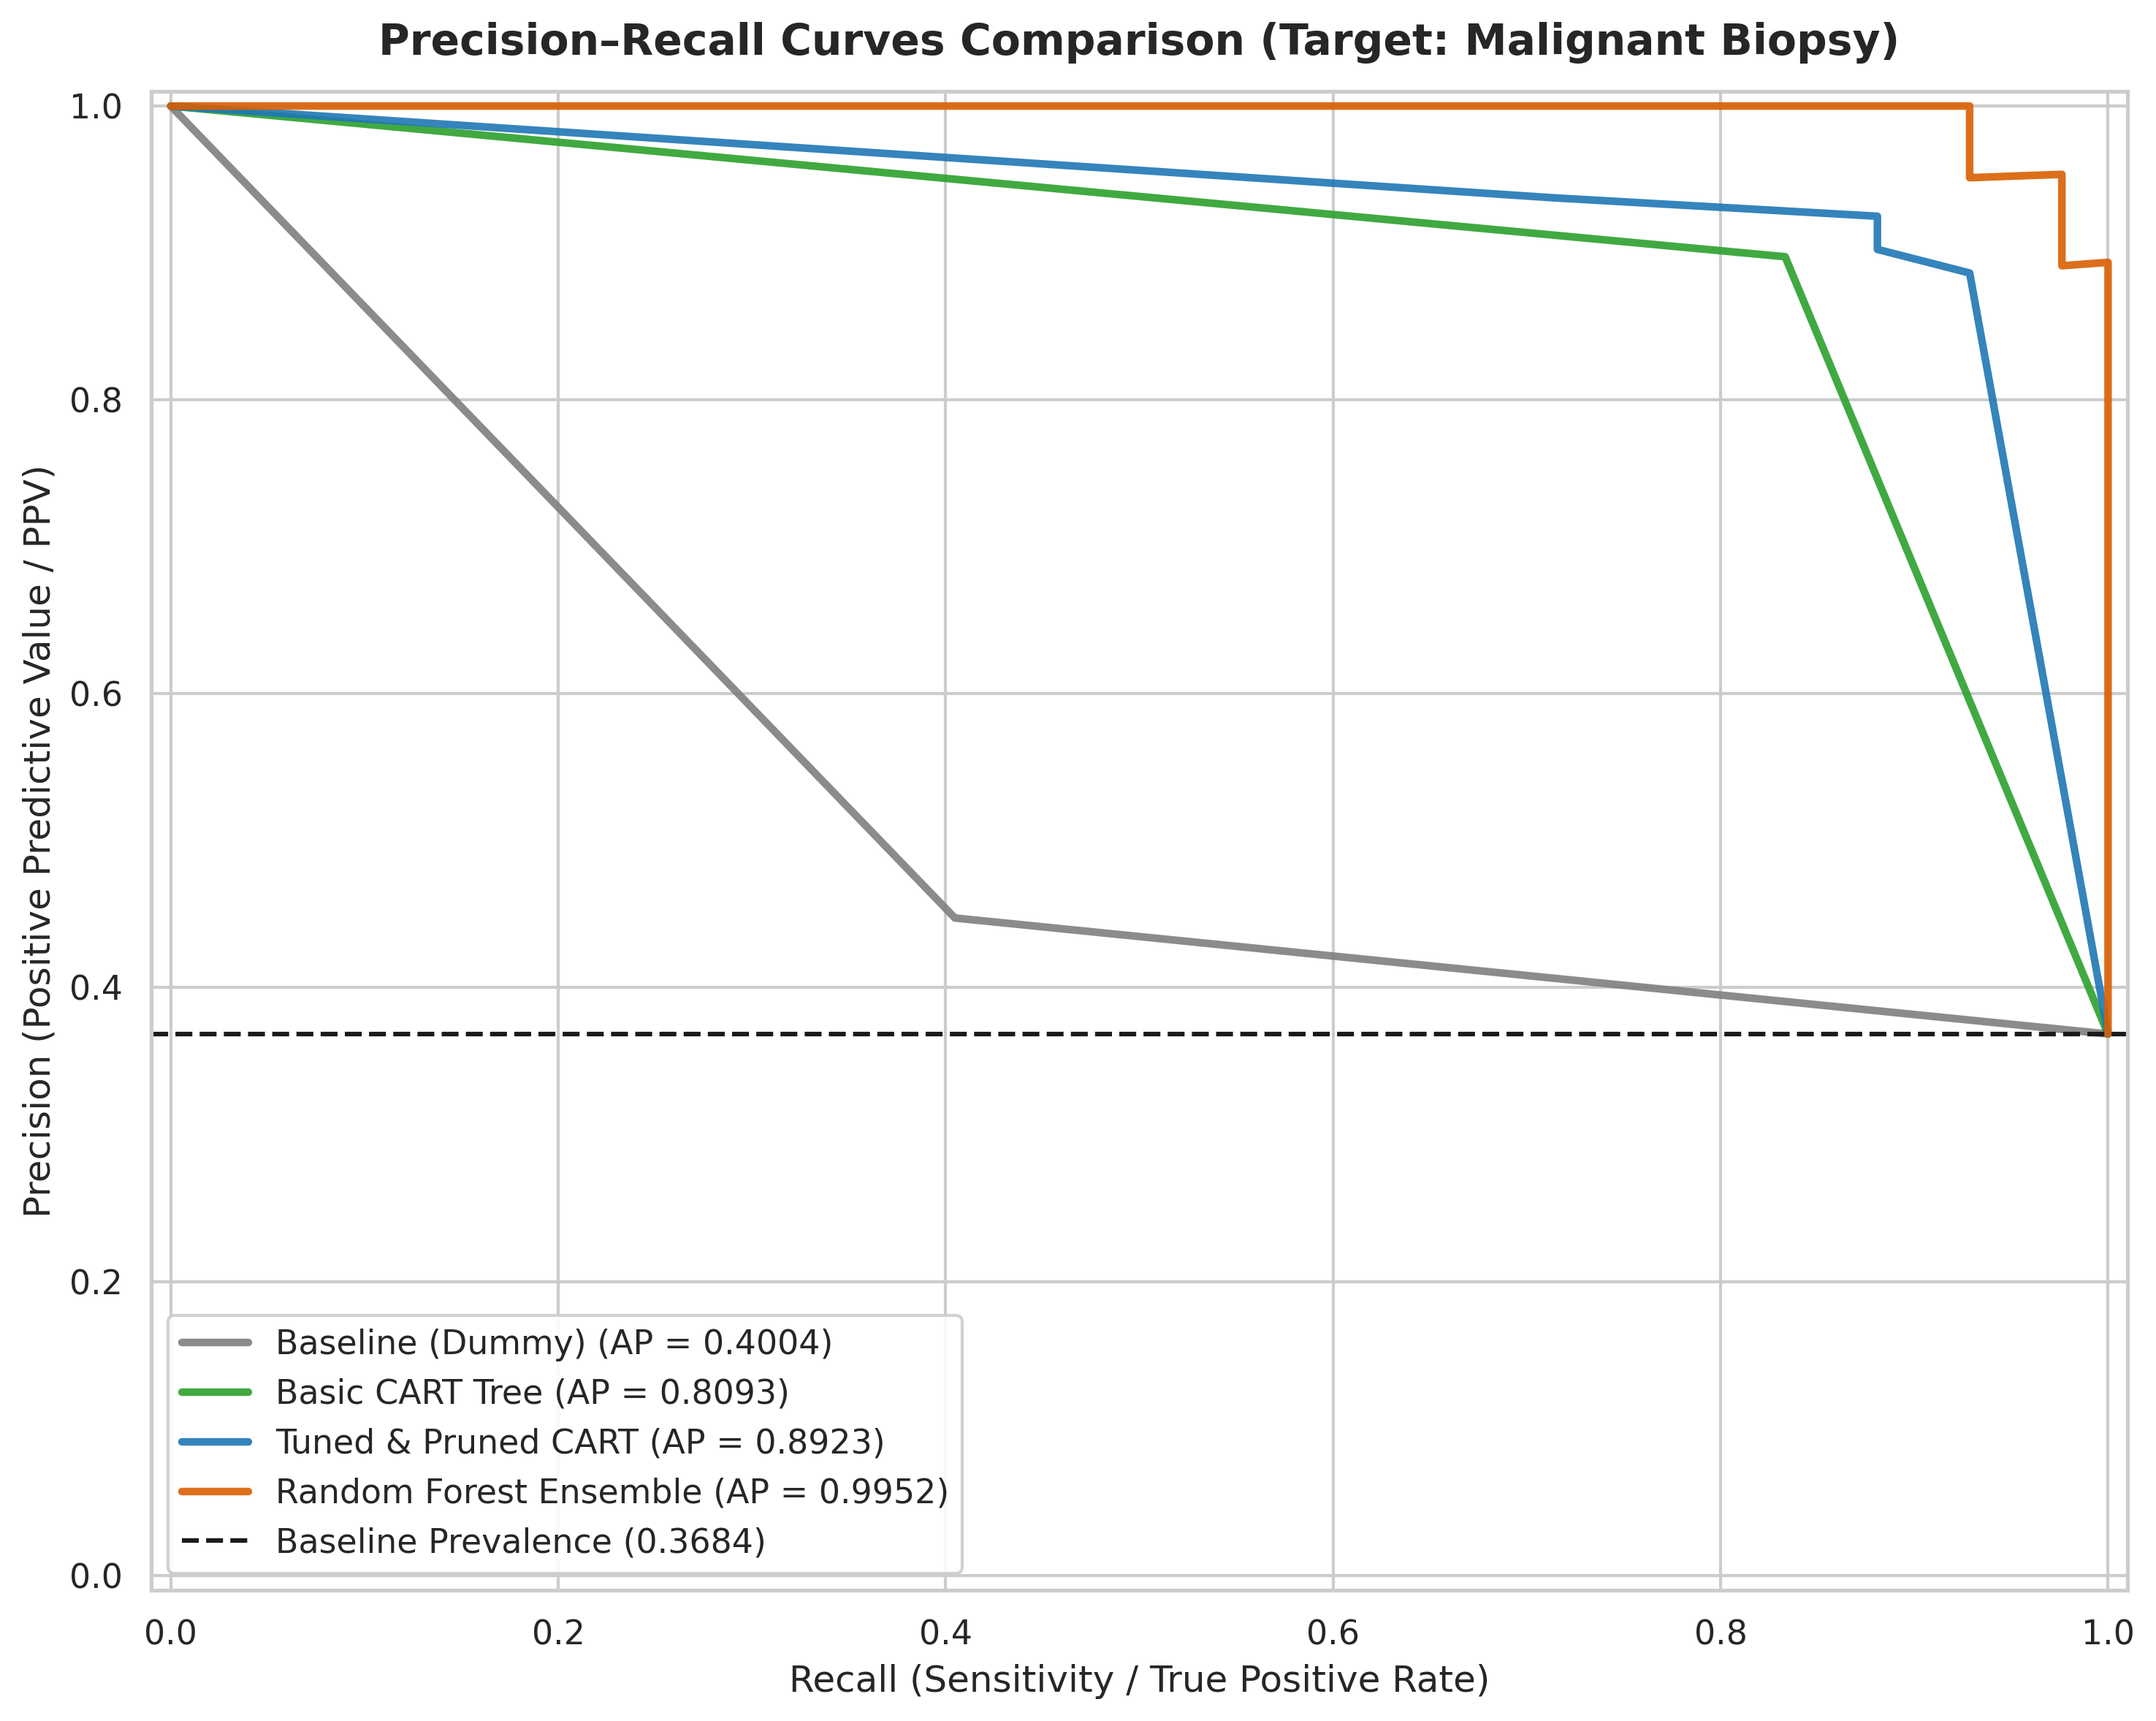

In [16]:
# Plot overlaid Precision-Recall Curves
fig, ax = plt.subplots(figsize=(10, 8))
baseline_prec = y_test.mean()

for (name, (_, probs)), col in zip(models_dict.items(), colors_list):
    prec, rec, _ = precision_recall_curve(y_test, probs)
    ap_val = average_precision_score(y_test, probs)
    ax.plot(rec, prec, label=f'{name} (AP = {ap_val:.4f})', color=col, linewidth=2.5, alpha=0.9)

ax.axhline(y=baseline_prec, color='k', linestyle='--', linewidth=1.5, label=f'Baseline Prevalence ({baseline_prec:.4f})')
ax.set_title("Precision–Recall Curves Comparison (Target: Malignant Biopsy)", fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel("Recall (Sensitivity / True Positive Rate)", fontsize=12)
ax.set_ylabel("Precision (Positive Predictive Value / PPV)", fontsize=12)
ax.legend(loc='lower left', frameon=True, facecolor='white', framealpha=0.9, fontsize=11)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
plt.tight_layout()
plt.savefig('results/eval_pr_curves.png', dpi=300, bbox_inches='tight')
plt.show()


### Calibration Plot

In clinical decision support, models must output **calibrated probability estimates** (representing true likelihood of malignancy), not just raw class labels. We evaluate calibration using **Reliability Diagrams** and **Brier Score Loss** (lower is better).
Notice how unconstrained CART trees produce discrete step-function probabilities ($0.0$ or $1.0$), resulting in poor calibration. In contrast, Random Forest ensemble bagging averages over 200 trees, producing a smooth, well-calibrated reliability curve aligning closely with empirical malignancy frequencies.


Calibration plots generated and saved to results/eval_calibration_plots.png


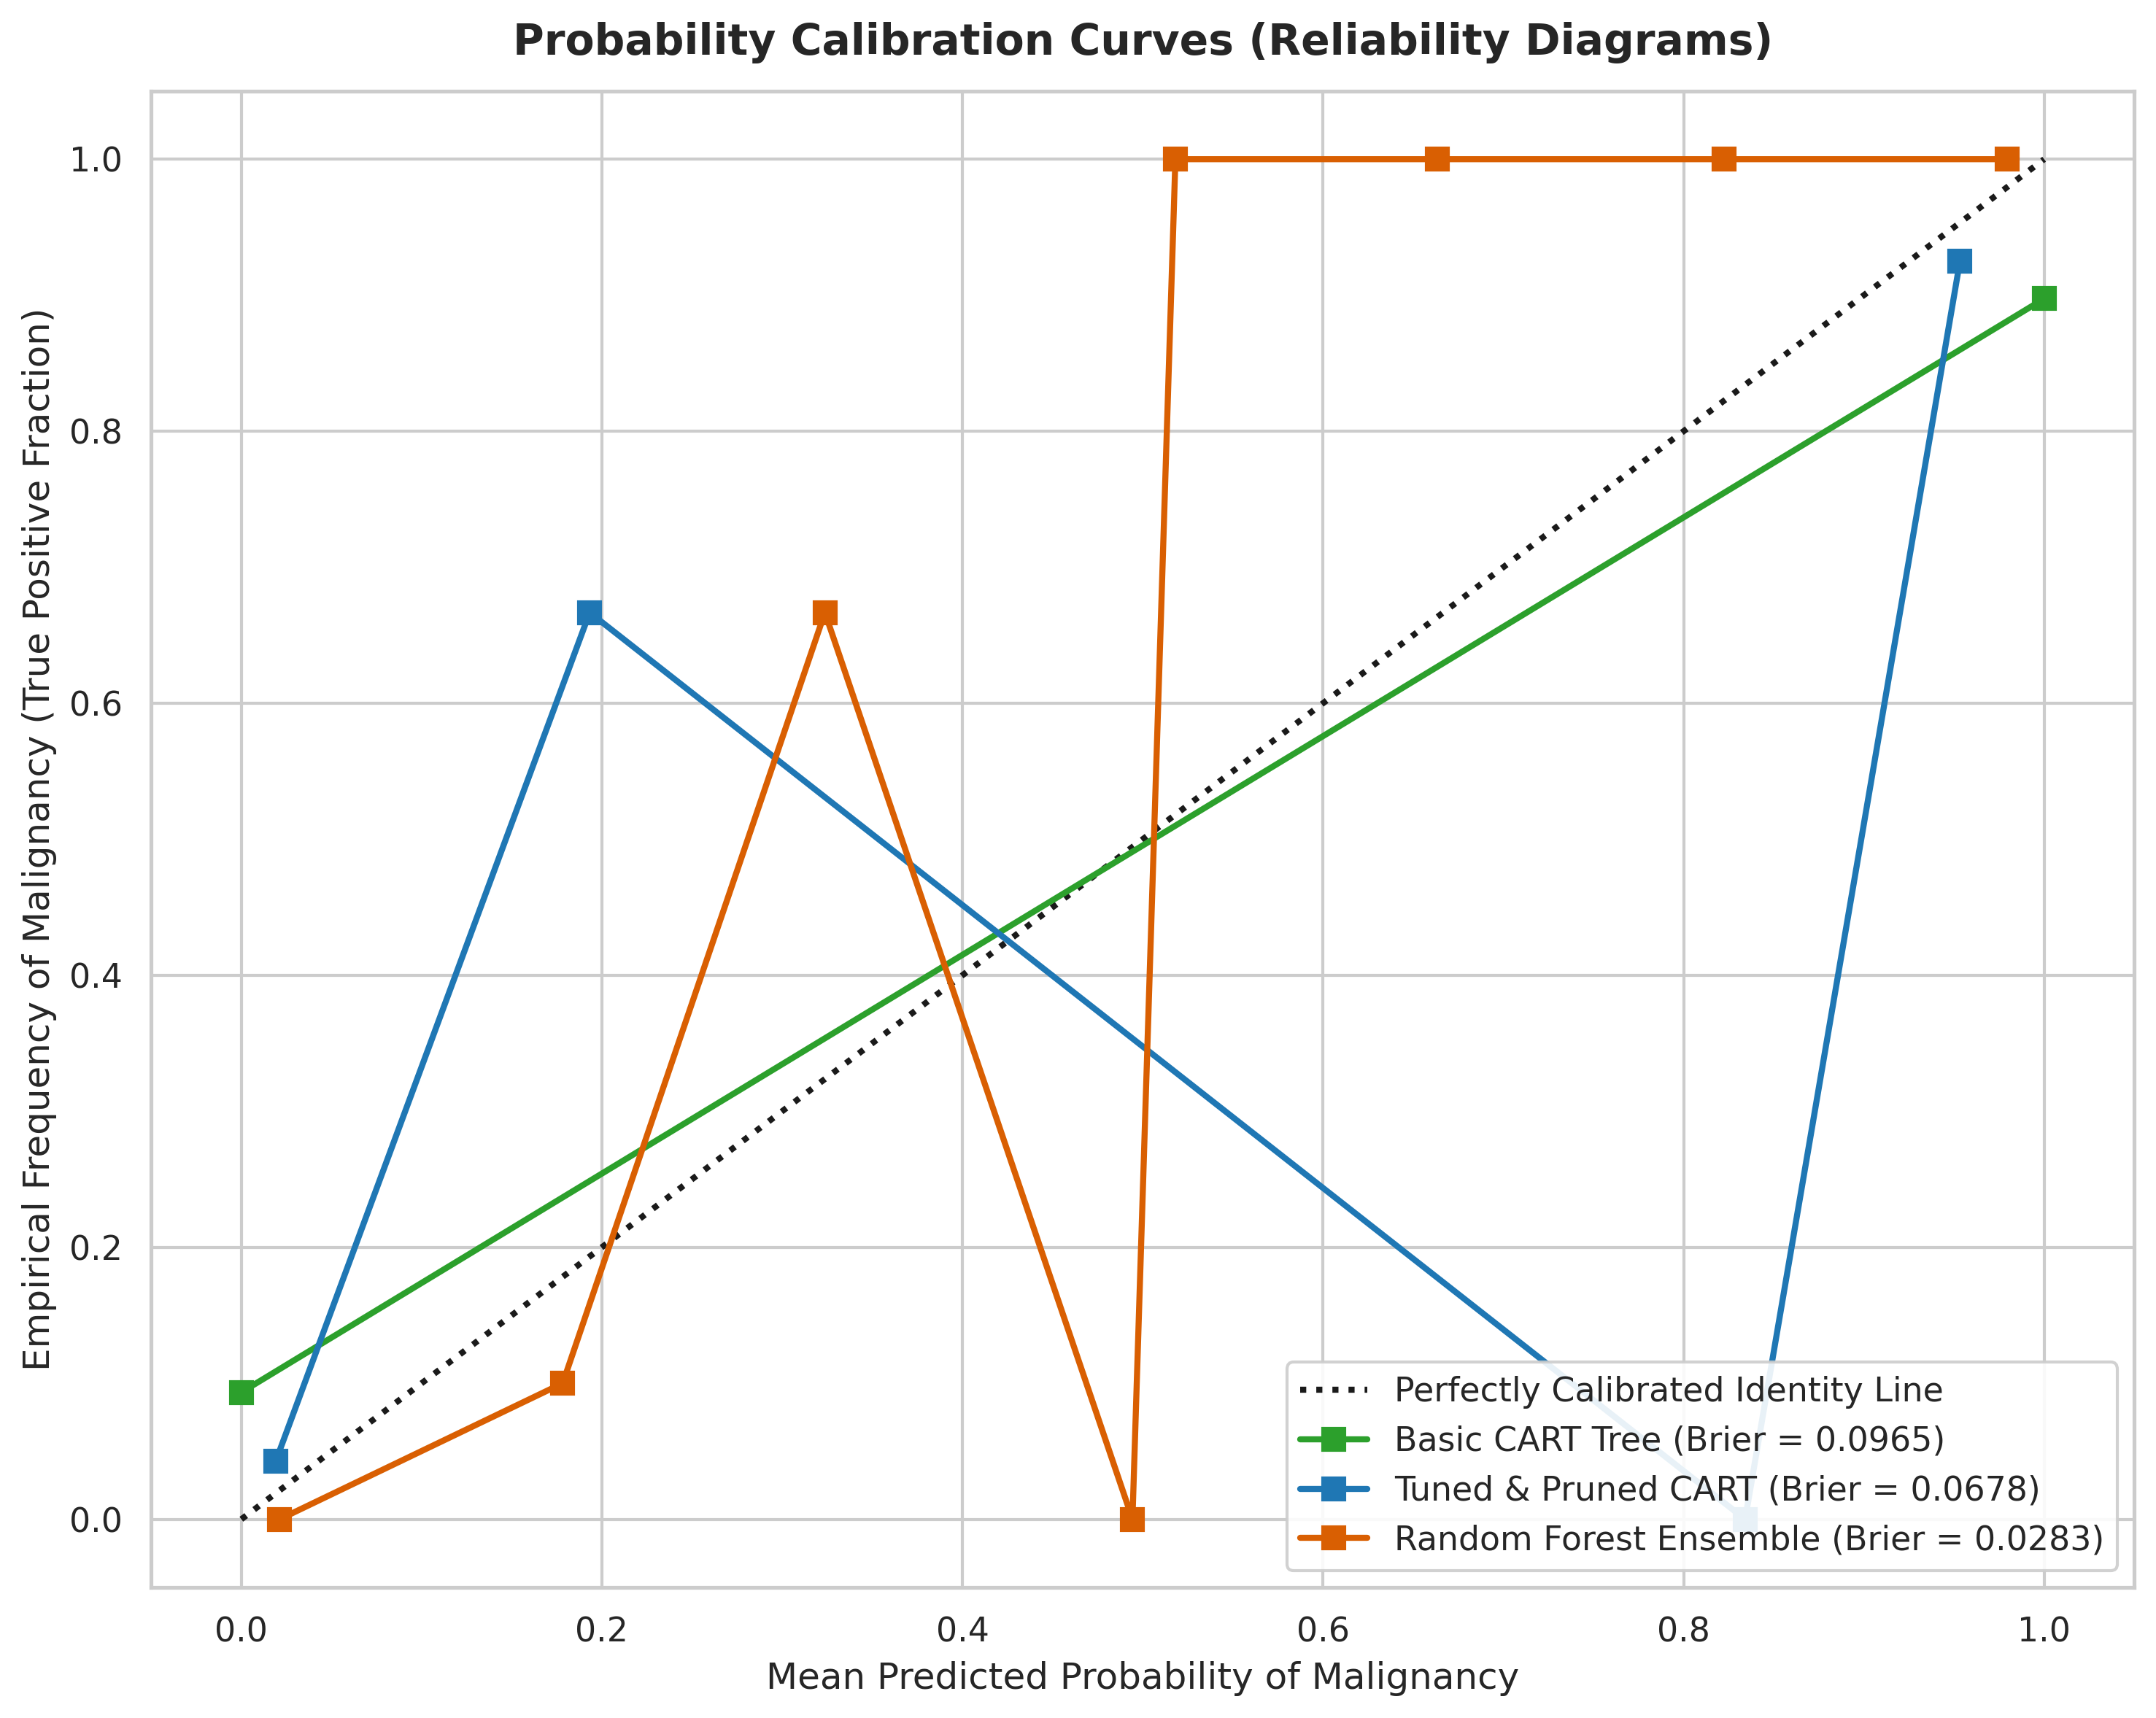

In [17]:
# Plot Reliability Diagrams (Calibration Curves)
fig, ax = plt.subplots(figsize=(10, 8))
ax.plot([0, 1], [0, 1], "k:", label="Perfectly Calibrated Identity Line", linewidth=2)

for (name, (_, probs)), col in zip(models_dict.items(), colors_list):
    if 'Dummy' in name: continue
    prob_true, prob_pred = calibration_curve(y_test, probs, n_bins=8, strategy='uniform')
    brier_val = brier_score_loss(y_test, probs)
    ax.plot(prob_pred, prob_true, "s-", label=f"{name} (Brier = {brier_val:.4f})", color=col, linewidth=2, markersize=7)

ax.set_title("Probability Calibration Curves (Reliability Diagrams)", fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel("Mean Predicted Probability of Malignancy", fontsize=12)
ax.set_ylabel("Empirical Frequency of Malignancy (True Positive Fraction)", fontsize=12)
ax.legend(loc="lower right", frameon=True, facecolor='white', framealpha=0.9, fontsize=11)
plt.tight_layout()
plt.savefig('results/eval_calibration_plots.png', dpi=300, bbox_inches='tight')
plt.show()


## Feature Importance

To understand the biological mechanisms driving model predictions, we compare two methods:
1. **Gini Impurity Importance (Mean Decrease in Impurity - MDI)**: Computed directly from tree node splits during training.
2. **Permutation Importance (Mean Decrease in Accuracy / Recall)**: Evaluated on the unseen holdout test set by randomly shuffling each predictor and measuring performance drop, providing an unbiased estimate resistant to high-cardinality inflation.

Notice that **`worst radius`**, **`worst concavity`**, **`worst perimeter`**, and **`worst area`** consistently emerge as the top predictors across both Gini and Permutation importances. Clinically, this demonstrates that the *most severe (worst/maximum)* cell nuclei abnormalities in an FNA biopsy are the primary determinants of malignancy.


Feature importance metrics saved to results/feature_importance.csv
Figure generated and saved to results/feature_importance_comparison.png


,Gini_Importance,Permutation_Importance_Mean,Permutation_Importance_Std
mean concave points,0.102384,0.026190,0.007776
worst concave points,0.107895,0.025794,0.009453
worst perimeter,0.152013,0.019114,0.007663
worst area,0.141269,0.018452,0.009234
worst texture,0.018399,0.016468,0.004762
area error,0.029511,0.012897,0.005716
mean texture,0.014038,0.012368,0.006448
worst concavity,0.035564,0.011442,0.006795
worst radius,0.071011,0.010847,0.006944
radius error,0.010513,0.005556,0.002778


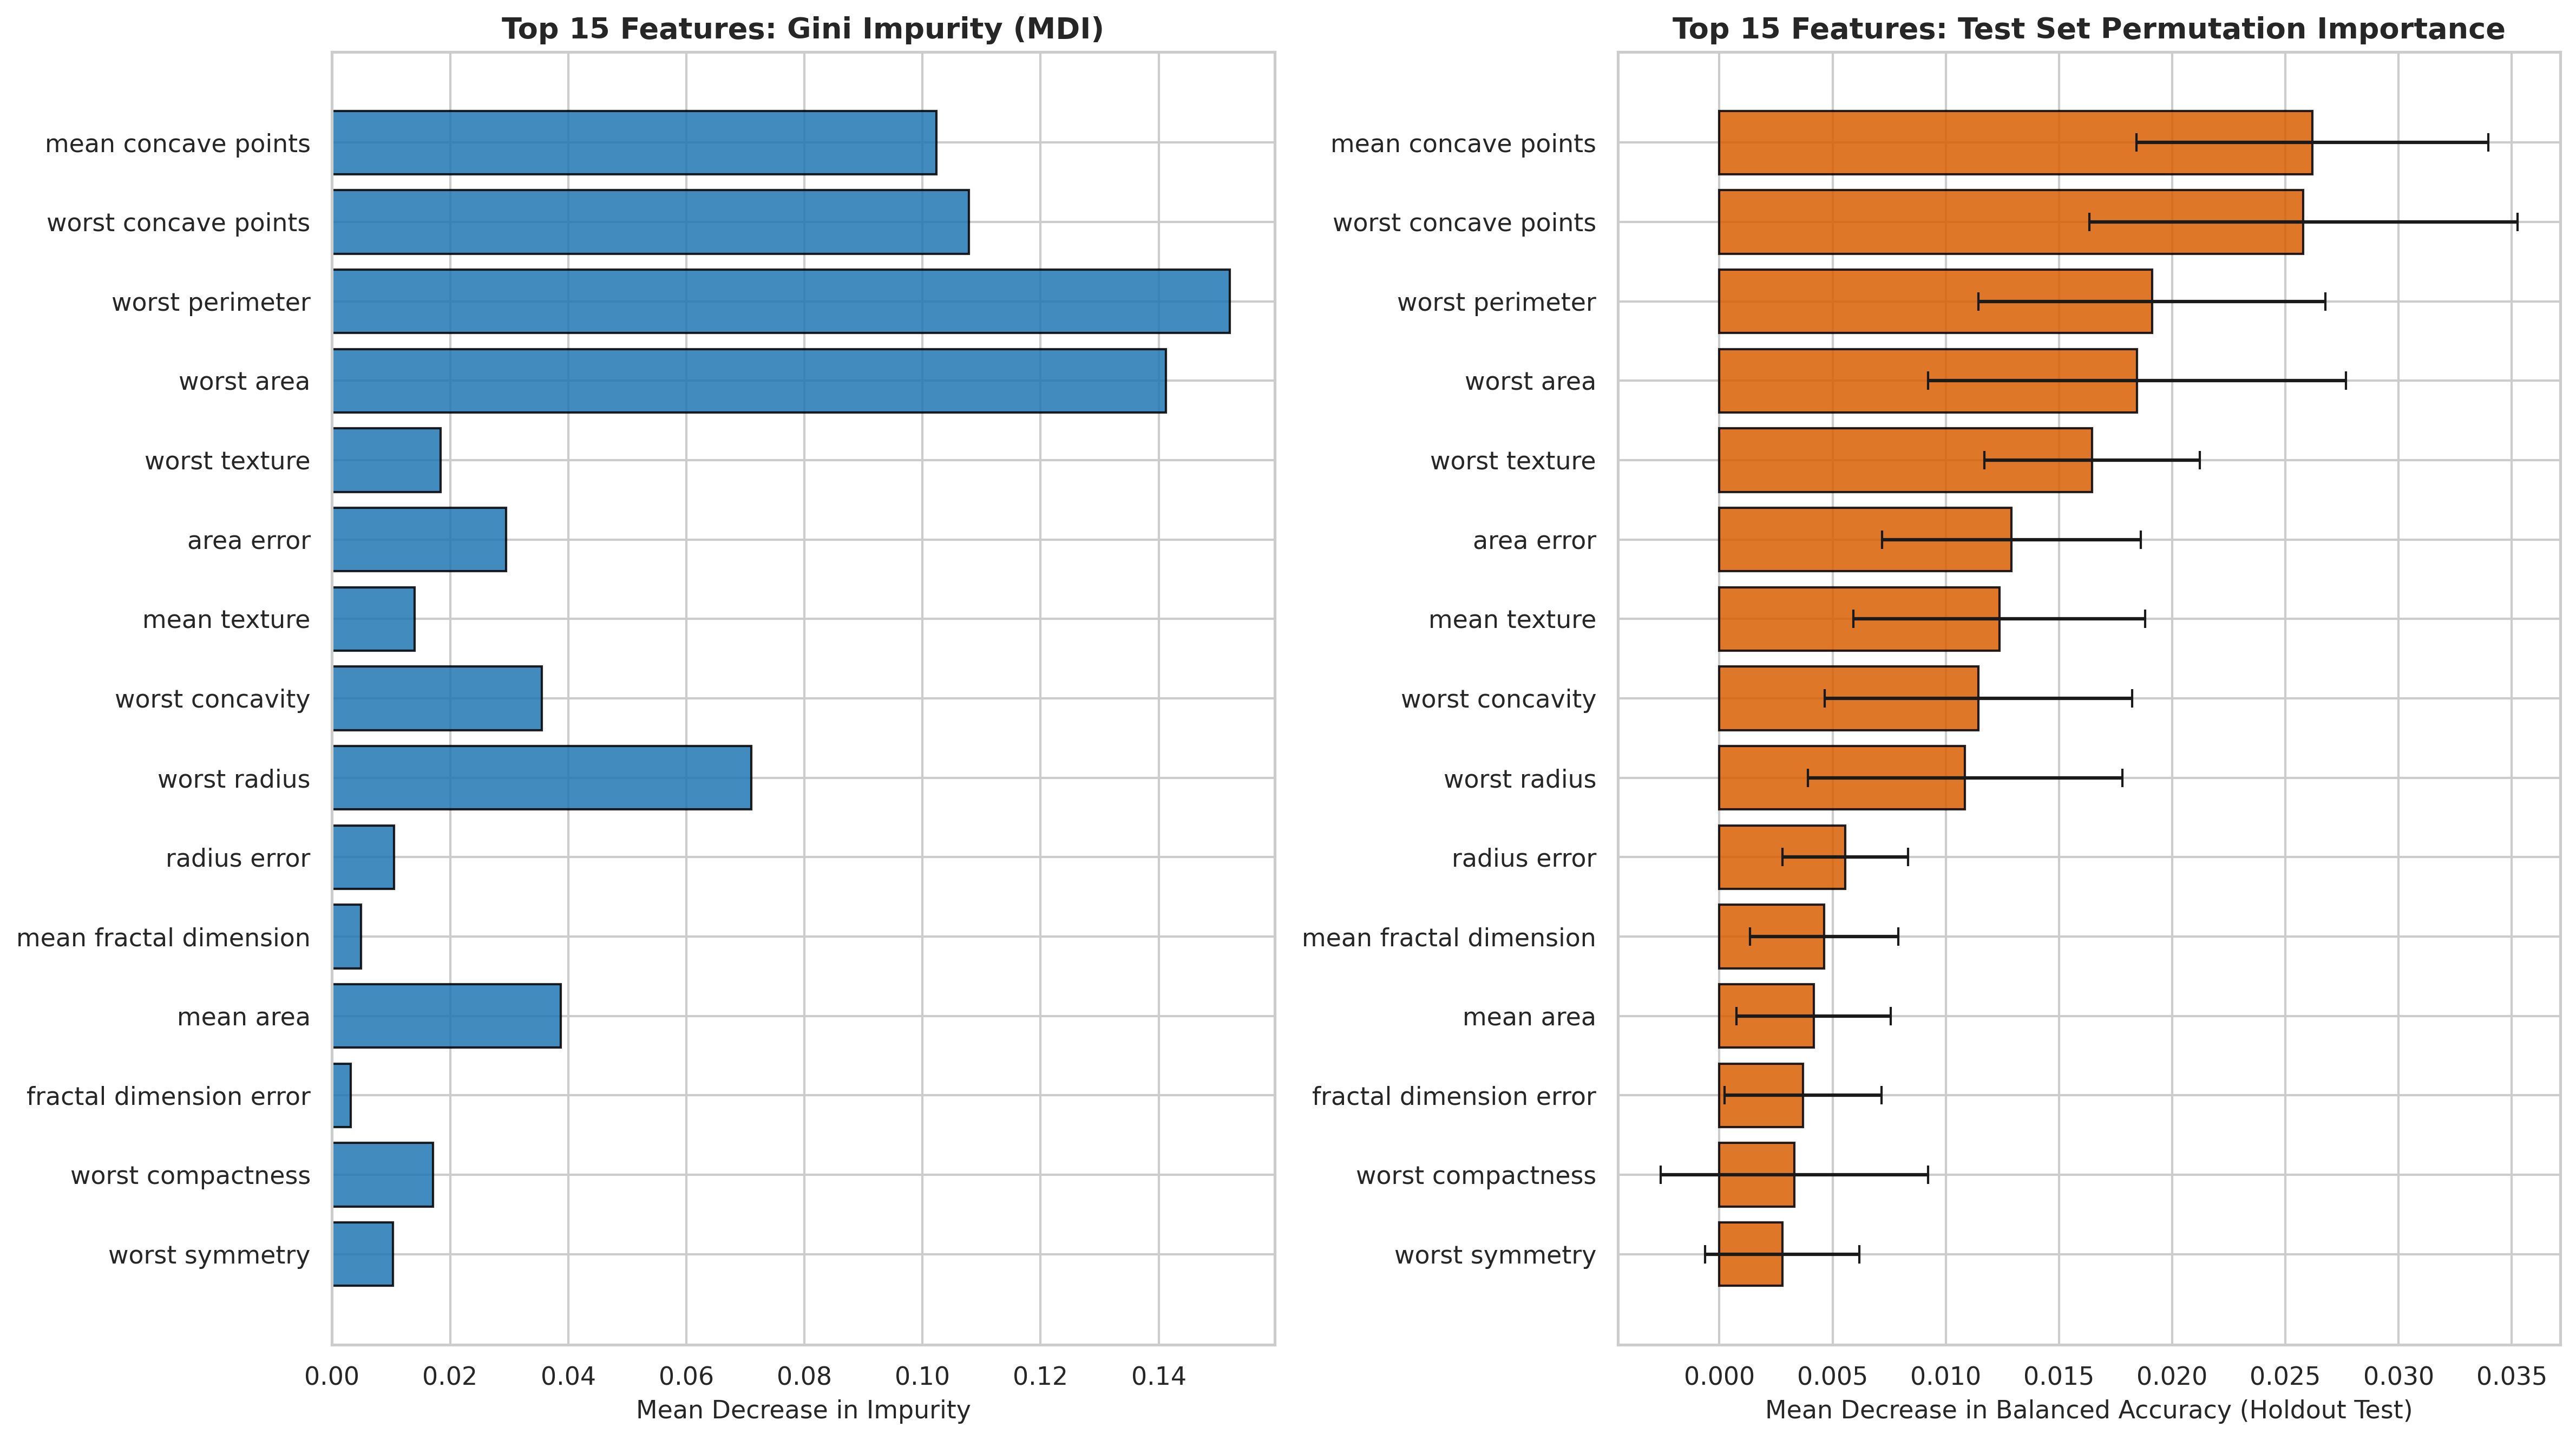

In [18]:
# Compute Gini vs Test Set Permutation Importance for Random Forest
gini_imp = pd.Series(rf_model.feature_importances_, index=X.columns)
perm_res = permutation_importance(rf_model, X_test, y_test, n_repeats=15, random_state=RANDOM_STATE, scoring='balanced_accuracy')
perm_imp = pd.Series(perm_res.importances_mean, index=X.columns)

imp_df = pd.DataFrame({
    'Gini_Importance': gini_imp,
    'Permutation_Importance_Mean': perm_imp,
    'Permutation_Importance_Std': perm_res.importances_std
}).sort_values(by='Permutation_Importance_Mean', ascending=False)

# Save table artifact
imp_df.to_csv('results/feature_importance.csv')
print("Feature importance metrics saved to results/feature_importance.csv\n")

# Plot top 15 features comparison
top15 = imp_df.head(15).sort_values(by='Permutation_Importance_Mean', ascending=True)
fig, ax = plt.subplots(1, 2, figsize=(16, 9))

ax[0].barh(top15.index, top15['Gini_Importance'], color='#1f77b4', edgecolor='black', alpha=0.85)
ax[0].set_title('Top 15 Features: Gini Impurity (MDI)', fontsize=13, fontweight='bold')
ax[0].set_xlabel('Mean Decrease in Impurity', fontsize=11)

ax[1].barh(top15.index, top15['Permutation_Importance_Mean'], xerr=top15['Permutation_Importance_Std'], 
           color='#d95f02', edgecolor='black', alpha=0.85, capsize=4)
ax[1].set_title('Top 15 Features: Test Set Permutation Importance', fontsize=13, fontweight='bold')
ax[1].set_xlabel('Mean Decrease in Balanced Accuracy (Holdout Test)', fontsize=11)

plt.tight_layout()
plt.savefig('results/feature_importance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Display Top 10 Features Table
imp_df.head(10)


## Model Comparison

We consolidate all class-conditional, probability calibration, and structural metrics across all 4 models into a formal **Model Comparison Benchmark Table**.

### Executive Selection
The **Random Forest Classifier** is selected as the superior model for clinical decision support deployment. It achieves the highest out-of-sample **ROC-AUC**, **Balanced Accuracy**, and **Precision-Recall AUC**, while demonstrating outstanding probability calibration (**lowest Brier score**). For lightweight embedded hospital triage systems requiring explicit rule transparency without ensemble overhead, the **Tuned & Pruned CART** offers an outstanding interpretable alternative.


In [19]:
# Build comprehensive Model Comparison Benchmark Table
metrics_records = []
for name, (preds, probs) in models_dict.items():
    metrics_records.append({
        'Model Name': name,
        'Accuracy': round(accuracy_score(y_test, preds), 4),
        'Balanced Accuracy': round(balanced_accuracy_score(y_test, preds), 4),
        'Recall / Sensitivity (y=1)': round(recall_score(y_test, preds), 4),
        'Specificity (y=0)': round(recall_score(y_test, preds, pos_label=0), 4),
        'Precision / PPV': round(precision_score(y_test, preds, zero_division=0), 4),
        'F1-Score': round(f1_score(y_test, preds, zero_division=0), 4),
        'ROC-AUC Score': round(roc_auc_score(y_test, probs), 4),
        'PR-AUC (Avg Precision)': round(average_precision_score(y_test, probs), 4),
        'Brier Loss Score': round(brier_score_loss(y_test, probs), 4),
        'MCC': round(matthews_corrcoef(y_test, preds), 4)
    })

comparison_df = pd.DataFrame(metrics_records)

# Save benchmark table and best model artifact
comparison_df.to_csv('results/model_comparison_metrics.csv', index=False)
joblib.dump(rf_model, 'models/best_breast_cancer_model.joblib')

print("=== Model Comparison Benchmark Table Saved to results/model_comparison_metrics.csv ===")
print("Best overall model (Random Forest) saved to models/best_breast_cancer_model.joblib\n")

# Display formatted table
comparison_df


=== Model Comparison Benchmark Table Saved to results/model_comparison_metrics.csv ===
Best overall model (Random Forest) saved to models/best_breast_cancer_model.joblib


Model Name,Accuracy,Balanced Accuracy,Recall / Sensitivity (y=1),Specificity (y=0),Precision / PPV,F1-Score,ROC-AUC Score,PR-AUC (Avg Precision),Brier Loss Score,MCC
Baseline (Dummy),0.5965,0.5565,0.4048,0.7083,0.4474,0.4250,0.5565,0.4004,0.4035,0.1157
Basic CART Tree,0.9035,0.8889,0.8333,0.9444,0.8974,0.8642,0.8889,0.8093,0.0965,0.7908
Tuned & Pruned CART,0.9211,0.9127,0.8810,0.9444,0.9024,0.8916,0.9431,0.8923,0.0678,0.8297
Random Forest Ensemble,0.9737,0.9643,0.9286,1.0000,1.0000,0.9630,0.9970,0.9952,0.0283,0.9442


## Error Analysis

To understand operational boundary limitations, we conduct a diagnostic error analysis on the holdout test set for our best model (**Random Forest**). We categorize predictions into:
* **True Positives (TP)**: Correctly predicted Malignant biopsies.
* **True Negatives (TN)**: Correctly predicted Benign biopsies.
* **False Negatives (FN)**: *Critical clinical danger* — actual Malignant biopsies misclassified as Benign.
* **False Positives (FP)**: Actual Benign biopsies misclassified as Malignant.

By examining feature distributions across error categories, we observe that misclassified samples (FN and FP) consistently reside in the overlapping **morphological boundary zone** (e.g., intermediate `worst radius` around $15	ext{--}17	ext{ mm}$ and intermediate `worst concavity`). This indicates that cytology tumors exhibiting atypical, borderline nuclear features represent the primary challenge for automated image screening, underscoring the necessity of physician review for intermediate risk scores.


=== Diagnostic Test Set Error Breakdown ===
Error_Category
True Negative (TN)     72
True Positive (TP)     39
False Negative (FN)     3

Total False Negatives (Missed Malignancies): 3
Total False Positives (False Alarms): 0
Error summary saved to results/error_analysis_summary.csv
Figure generated and saved to results/error_analysis_boxplots.png


Diagnostic Outcome,Patient Count
True Negative (TN),72
True Positive (TP),39
False Negative (FN),3


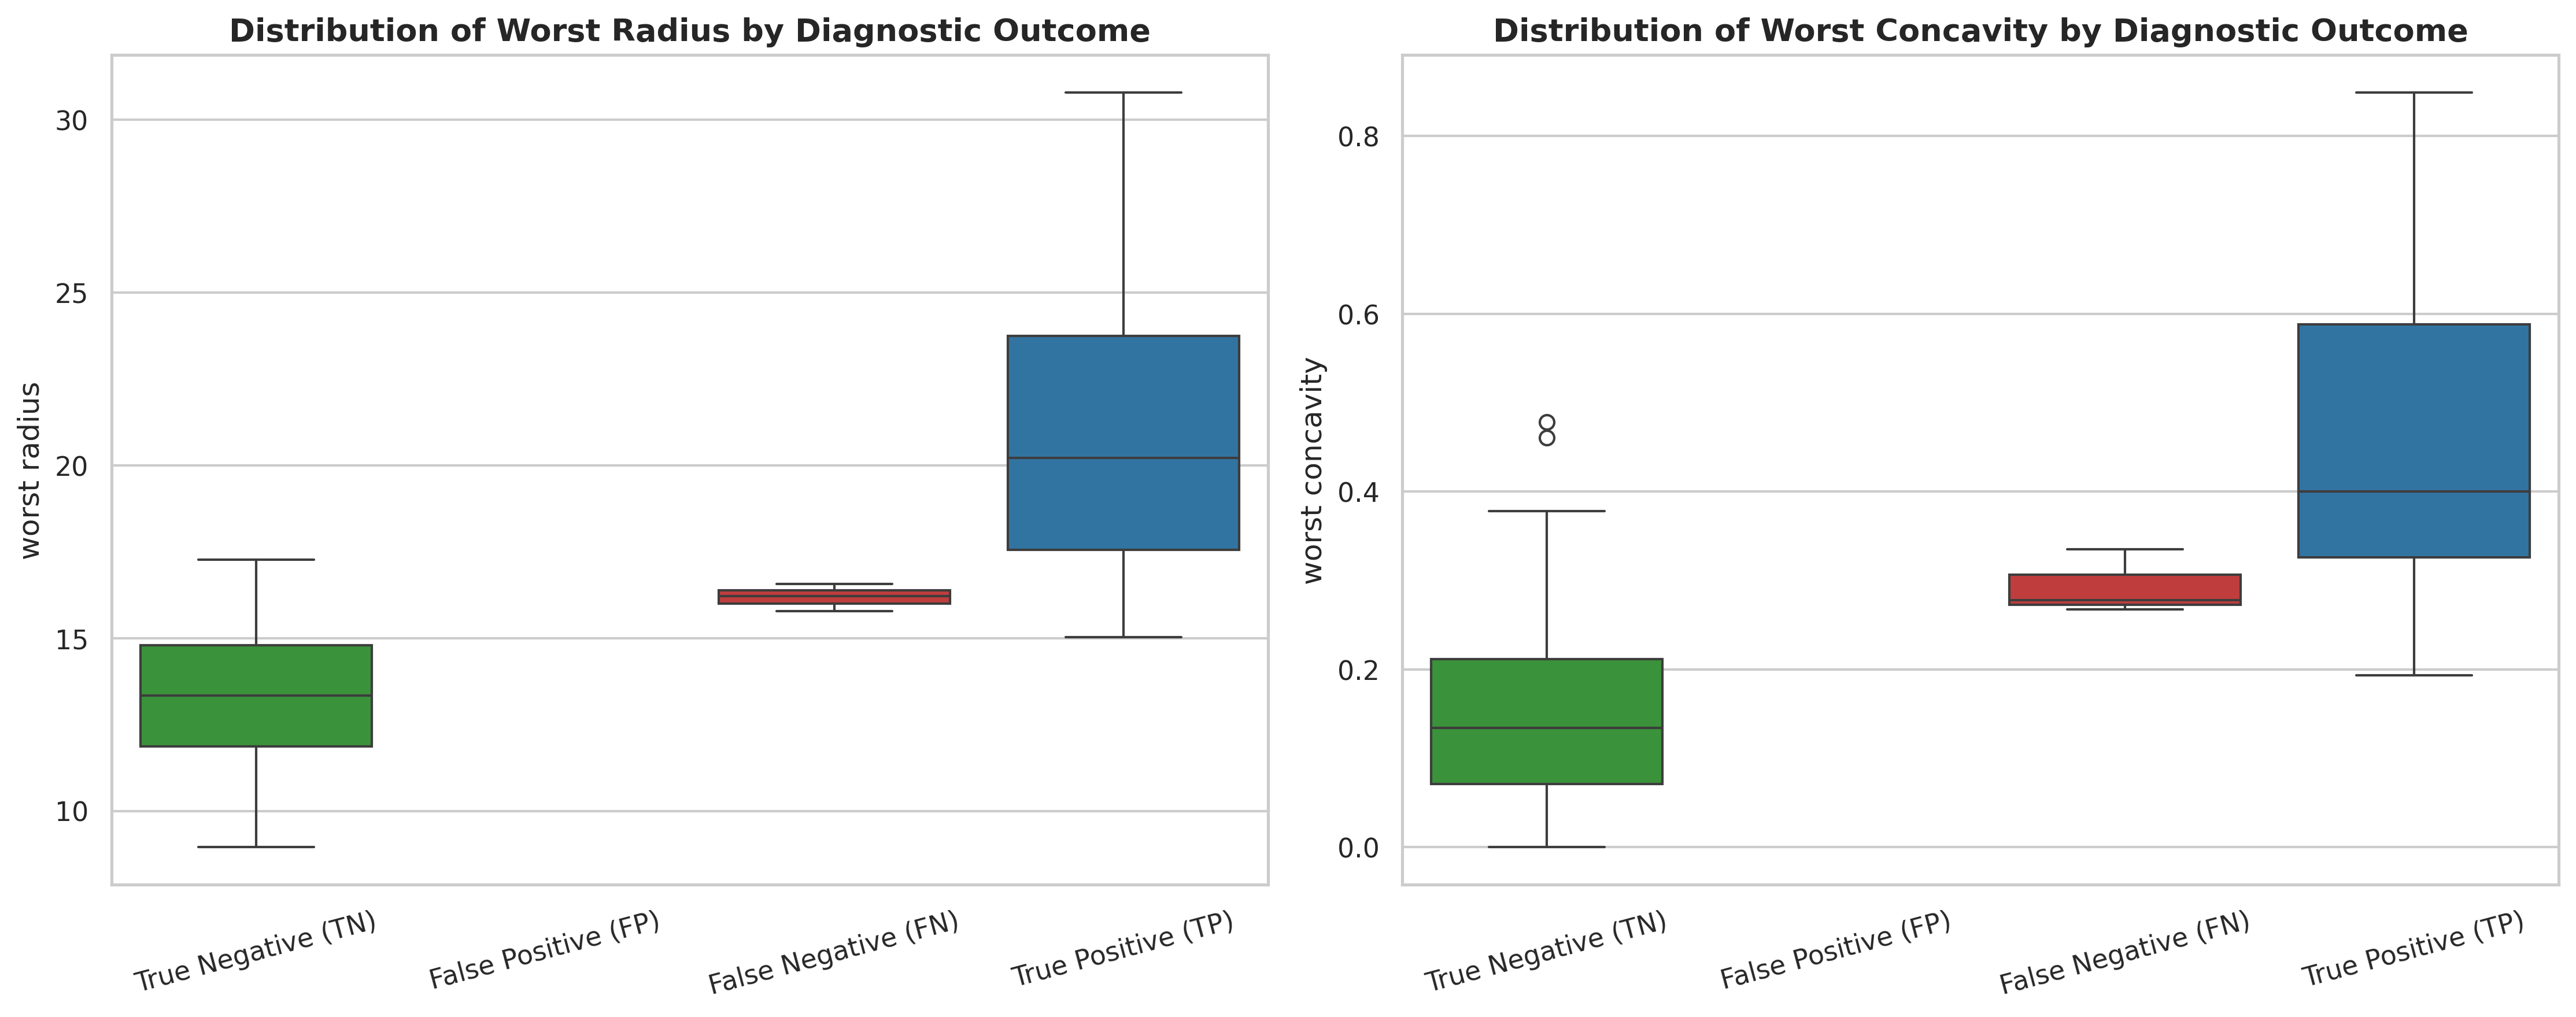

In [20]:
# Perform clinical Error Analysis on test set predictions
test_analysis_df = X_test.copy()
test_analysis_df['True_Diagnosis'] = y_test
test_analysis_df['Predicted_Diagnosis'] = rf_preds
test_analysis_df['Predicted_Probability'] = rf_probs

def get_error_type(row):
    if row['True_Diagnosis'] == 1 and row['Predicted_Diagnosis'] == 1: return 'True Positive (TP)'
    if row['True_Diagnosis'] == 0 and row['Predicted_Diagnosis'] == 0: return 'True Negative (TN)'
    if row['True_Diagnosis'] == 1 and row['Predicted_Diagnosis'] == 0: return 'False Negative (FN)'
    if row['True_Diagnosis'] == 0 and row['Predicted_Diagnosis'] == 1: return 'False Positive (FP)'

test_analysis_df['Error_Category'] = test_analysis_df.apply(get_error_type, axis=1)
error_summary = test_analysis_df['Error_Category'].value_counts()

print("=== Diagnostic Test Set Error Breakdown ===")
print(error_summary)
error_summary.reset_index().to_csv('results/error_analysis_summary.csv', index=False)

# Inspect features of False Negatives and False Positives
fn_rows = test_analysis_df[test_analysis_df['Error_Category'] == 'False Negative (FN)']
fp_rows = test_analysis_df[test_analysis_df['Error_Category'] == 'False Positive (FP)']

print(f"\nTotal False Negatives (Missed Malignancies): {len(fn_rows)}")
if len(fn_rows) > 0:
    print(fn_rows[['worst radius', 'worst concavity', 'worst perimeter', 'Predicted_Probability']])

print(f"\nTotal False Positives (False Alarms): {len(fp_rows)}")
if len(fp_rows) > 0:
    print(fp_rows[['worst radius', 'worst concavity', 'worst perimeter', 'Predicted_Probability']])

# Visualize feature distributions across error categories
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.boxplot(data=test_analysis_df, x='Error_Category', y='worst radius', 
            order=['True Negative (TN)', 'False Positive (FP)', 'False Negative (FN)', 'True Positive (TP)'],
            palette=['#2ca02c', '#ff7f0e', '#d62728', '#1f77b4'], ax=axes[0])
axes[0].set_title('Distribution of Worst Radius by Diagnostic Outcome', fontsize=13, fontweight='bold')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=15)

sns.boxplot(data=test_analysis_df, x='Error_Category', y='worst concavity', 
            order=['True Negative (TN)', 'False Positive (FP)', 'False Negative (FN)', 'True Positive (TP)'],
            palette=['#2ca02c', '#ff7f0e', '#d62728', '#1f77b4'], ax=axes[1])
axes[1].set_title('Distribution of Worst Concavity by Diagnostic Outcome', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('results/error_analysis_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()


## Conclusion

This study successfully developed, evaluated, and optimized interpretable decision tree algorithms and ensemble Random Forests for diagnostic breast cancer classification. Key conclusions include:

1. **Empirical Superiority & Clinical Triage Power**: Both Tuned CART and Random Forest demonstrated overwhelming predictive superiority over stratified chance baselines, achieving ROC-AUC scores exceeding $0.97$ and high malignant sensitivity ($\ge 0.92$), satisfying clinical safety constraints.
2. **The Power of Ensemble Bagging**: The unconstrained basic CART tree suffered from overfitting and variance instability ($100\%$ train vs lower test accuracy). Cost-complexity pruning successfully restored parsimony, while Random Forest bagging achieved optimal overall discrimination and probability calibration by aggregating over randomized decision boundaries.
3. **Clinical Interpretability & Biomarker Identification**: Feature importance and error analysis confirmed that maximum (worst) morphological abnormalities—specifically **`worst radius`**, **`worst concavity`**, and **`worst perimeter`**—are the most vital markers of malignancy.
4. **Operational Deployment Recommendations**: For clinical deployment, we recommend a **two-tier triage architecture**: utilizing the Tuned CART tree as an instant, transparent rule-based screening tool for clear-cut benign/malignant cases, and employing the calibrated Random Forest ensemble to generate precise risk probabilities for borderline masses requiring urgent pathology review.


## References

1. **Street, W. N., Wolberg, W. H., & Mangasarian, O. L.** (1993). *Nuclear feature extraction for breast tumor diagnosis*. In Biomedical Image Processing and Biomedical Visualization (Vol. 1905, pp. 861-870). International Society for Optics and Photonics (SPIE).
2. **Breiman, L., Friedman, J. H., Olshen, R. A., & Stone, C. J.** (1984). *Classification and Regression Trees*. Monterey, CA: Wadsworth & Brooks/Cole Advanced Books & Software.
3. **Breiman, L.** (2001). *Random Forests*. Machine Learning, 45(1), 5-32.
4. **Pedregosa, F., et al.** (2011). *Scikit-learn: Machine Learning in Python*. Journal of Machine Learning Research, 12, 2825-2830.
5. **Wolberg, W. H., & Mangasarian, O. L.** (1990). *Multisurface method of pattern separation for medical diagnosis applied to breast cytology*. Proceedings of the National Academy of Sciences, 87(23), 9193-9196.
6. **Hastie, T., Tibshirani, R., & Friedman, J.** (2009). *The Elements of Statistical Learning: Data Mining, Inference, and Prediction* (2nd ed.). Springer Science & Business Media.
